This file contains the code to generate the parameters and plots of the article "Acute Smurf mortality and inter-phase dependence in Drosophila and mice identified through comprehensive modelling and statistical analysis of two-phase ageing." by L. Breuil, M.Doumic, S. Kaakai and M.Rera

In [ ]:
#run if packages needed 

install.packages('viridis')
install.packages('logKDE')
install.packages('ggplot2')
install.packages('tidyr')
install.packages('latex2exp')
install.packages('gtools')
install.packages('gridExtra')
install.packages('mice')
install.packages('transport')
install.packages('EnvStats')
install.packages('pracma')
install.packages('dplyr')
install.packages('ggpubr')
install.packages('survival')
install.packages('WeibullFit')
install.packages('weibullness')
install.packages('expm')
install.packages('numDeriv')
install.packages('pwr')
install.packages('logKDE')
install.packages('TeachingDemos')
install.packages('expint')
install.packages('eha')
install.packages('diffusion')
install.packages('OneR')
install.packages('MortalityLaws')
install.packages('flexsurv')
install.packages('evmix')
install.packages('kdensity')
install.packages('CVXR')
install.packages('RColorBrewer')


Les packages binaires téléchargés sont dans
	/var/folders/m4/9hh01lj10mvb1yb0swr1vj3mhj6200/T//RtmpcfIe2g/downloaded_packages

Les packages binaires téléchargés sont dans
	/var/folders/m4/9hh01lj10mvb1yb0swr1vj3mhj6200/T//RtmpcfIe2g/downloaded_packages

Les packages binaires téléchargés sont dans
	/var/folders/m4/9hh01lj10mvb1yb0swr1vj3mhj6200/T//RtmpcfIe2g/downloaded_packages

Les packages binaires téléchargés sont dans
	/var/folders/m4/9hh01lj10mvb1yb0swr1vj3mhj6200/T//RtmpcfIe2g/downloaded_packages

Les packages binaires téléchargés sont dans
	/var/folders/m4/9hh01lj10mvb1yb0swr1vj3mhj6200/T//RtmpcfIe2g/downloaded_packages

Les packages binaires téléchargés sont dans
	/var/folders/m4/9hh01lj10mvb1yb0swr1vj3mhj6200/T//RtmpcfIe2g/downloaded_packages

Les packages binaires téléchargés sont dans
	/var/folders/m4/9hh01lj10mvb1yb0swr1vj3mhj6200/T//RtmpcfIe2g/downloaded_packages

Les packages binaires téléchargés sont dans
	/var/folders/m4/9hh01lj10mvb1yb0swr1vj3mhj6200/T//RtmpcfIe2g/down

In [181]:
#source code files
source('./Simulation.R')
source('./Estimation.R')


#loading packages 
library('IBMPopSim')
library(viridis)
library('WeibullFit')
library('transport')
library('weibullness')
library('expm')
library('numDeriv')
library('pwr')
library('logKDE')
library('ggplot2')
library(tidyr)
library(latex2exp)
library('gtools')
library('RColorBrewer')
library('expint')
library('eha')
library('diffusion')
library('OneR')
library('MortalityLaws')
library('flexsurv')
library(gridExtra)
library(mice)
library(pracma)
library(dplyr)
library('ggpubr')
library('CVXR')

In [92]:
#loading data and defining some arrays
times_exp = read.csv('./Data/times_exp') #experimental data
TNS = times_exp$Smurf #time spent non-smurf
TS = times_exp$Death #time spent smurf
TD= TS+TNS #age at death
N = length(TNS) #population size
q95 = qnorm(0.975) #quantile of normal distribution for confidence intervals
mycol <- rgb(128, 128, 128, max = 255, alpha = 75, names = "lt.grey")
colo <- rgb(250,0,0,max = 255,alpha=50)
smurf_exp = sapply(1:1100, function(x) (Smurf_1_2(x,TNS,TS)))#experimental smurf population
tot_exp = sapply(1:1100, stepfun(sort(TD), N:0)) #experimental total population
q95 = qnorm(0.975) #quantile of normal distribution for confidence intervals
theme = theme_bw(base_size = 30)+ theme(legend.position = c(0.6,0.9),legend.text = element_text(size=30),
                                legend.background=element_rect(fill = alpha("white", 0)))


#Grids and bandwidth sets for non-parametric estimation
Grid_expd = c((1:20)/10, (2:350)*2 ) 
Grid_exp = (0:1000)
Grid_exps = (0:1000)

Bset1 = c((3:10)/5,2,3,4,5,7,9)
Bset2 = c((1:10)/5)
Bset = c((3:10)/5,2,3,4,5,7,9,14,18,20)

# Nonparametric statistics (Section Results 1)

In [4]:
#quantitative description
print(paste('Data size:', N))
print(paste('Mean time spent non-Smurf:',mean(TNS),'hours'))
print(paste('Mean time spent Smurf:',mean(TS),'hours'))
print(paste('Mean lifetime :',mean(TD),'hours'))
print(paste('Correlation coefficient between time spent non-Smurf and Smurf',cor(TNS,TS)))
print(paste('Percentage of flies dying within 24 hours Smurf:', 100*length(TS[TS <=24])/N, '%'))

[1] "Data size: 1159"
[1] "Mean time spent non-Smurf: 387.377342129682 hours"
[1] "Mean time spent Smurf: 92.819530784415 hours"
[1] "Mean lifetime : 480.196872914097 hours"
[1] "Correlation coefficient between time spent non-Smurf and Smurf -0.164392286821093"
[1] "Percentage of flies dying within 24 hours Smurf: 39.6893874029336 %"


### Figure 2

In [156]:
#Non-parametric hazard kernel estimators for the transition and death rates

#apparent death hazard rate
RES = minimax_pointwise_data(sort(TD),Grid_exp,B=Bset) 
Kopt = RES$K #adaptive bandwidth estimator
Bopt = RES$B #chosen local bandwidths 
gam_adapt  = IBMPopSim::linfun(Grid_exp, Kopt,0,0) #gamma kernel estimator for simulation

#Smurf transition rate
RESs = minimax_pointwise_data(sort(TNS),Grid_exps,B = Bset1) 
Kopts = RESs$K #adaptive bandwidth estimator
Bopts = RESs$B #chosen local bandwidths 
gam_adapt_s  = IBMPopSim::linfun(Grid_exps, Kopts,0,0) #gamma kernel estimator for simulation

#Death hazard rate once Smurf
RESd = minimax_pointwise_data(sort(TS),Grid_expd, B = Bset2) 
Koptd = RESd$K #adaptive bandwidth estimator
Boptd = RESd$B #chosen local bandwidths 
gam_adapt_d  = IBMPopSim::linfun(Grid_expd, Koptd,0,0) #gamma kernel estimator for simulation

In [ ]:
#to produce 95% theoretical CI with monte-carlo, quite long so we download the array of variances instead in the next cell

#n=30000 #number of repetitions for monte-carlo
#max = 5000 #maximum bound for integral of square kernel (as close to infinity as possible)
#ker_est = function(y,b)(ker_est_gamma_c(y,TS,b)) #kernel estimator
#Var_S = sapply(1:length(Grid_exps), function(i)(Var_M_C_b(Grid_exps[i],N,gamma_ker,ker_est,n,Bopts[i],max))) #Array of variances 
#write.csv(Var_S, 'Var_death_mx.csv')
#Var_Dtot = sapply(1:length(Grid_exp), function(i)(Var_M_C_b(Grid_exp[i],N,gamma_ker,ker_estd,n,Bops[i],max)))
#write.csv(Var_Dtot, 'Var_death_tot.csv')

In [7]:
#95% CI for the non-parametric kernel estimators
Var_S = read.csv('./Data/Var_smurf_mx.csv') #Variance of non-parametric estimator of Smurf transition rate to compute theoretical CI
CI_sup = log(q95*sqrt(Var_S$x)+Kopts)
CI_inf = log(-q95*sqrt(Var_S$x)+Kopts)
CI_inf = na.replace(CI_inf,-10)
CI_inf = na.omit(CI_inf)

Var_D = read.csv('./Data/Var_death_mx.csv') #Variance of non-parametric estimator of death rate once Smurf to compute theoretical CI
CI_supd = log(q95*sqrt(Var_D$x)+Koptd)
CI_infd = log(-q95*sqrt(Var_D$x)+Koptd)
CI_infd = na.replace(CI_infd,-10)

Var_D_tot = read.csv('./Data/Var_death_tot.csv') #Variance of non-parametric estimator of overall death hazard rate to compute theoretical CI
CI_supdt = log(q95*sqrt(Var_D_tot$x)+Kopt)
CI_infdt = log(-q95*sqrt(Var_D_tot$x)+Kopt)
CI_infdt = na.replace(CI_infdt,-10)

#Empirical 95% confidence bands for the survival curves based on simulations

CI = NS_CI('np','np',gam_adapt_s, gam_adapt_d,sort(TNS),nrep = 500) #survival as non-Smurf

CIS = S_CI('np','np',gam_adapt_s, gam_adapt_d,sort(TS),nrep = 500) #survival as Smurf

CId = NS_CI('np','np',gam_adapt, gam_adapt_d,sort(TD),nrep = 500) #classical population survival 

Warning message in q95 * sqrt(Var_S$x) + Kopts:
“la taille d'un objet plus long n'est pas multiple de la taille d'un objet plus court”
Warning message in -q95 * sqrt(Var_S$x) + Kopts:
“la taille d'un objet plus long n'est pas multiple de la taille d'un objet plus court”
Warning message in log(-q95 * sqrt(Var_S$x) + Kopts):
“Production de NaN”
Warning message in log(-q95 * sqrt(Var_D$x) + Koptd):
“Production de NaN”


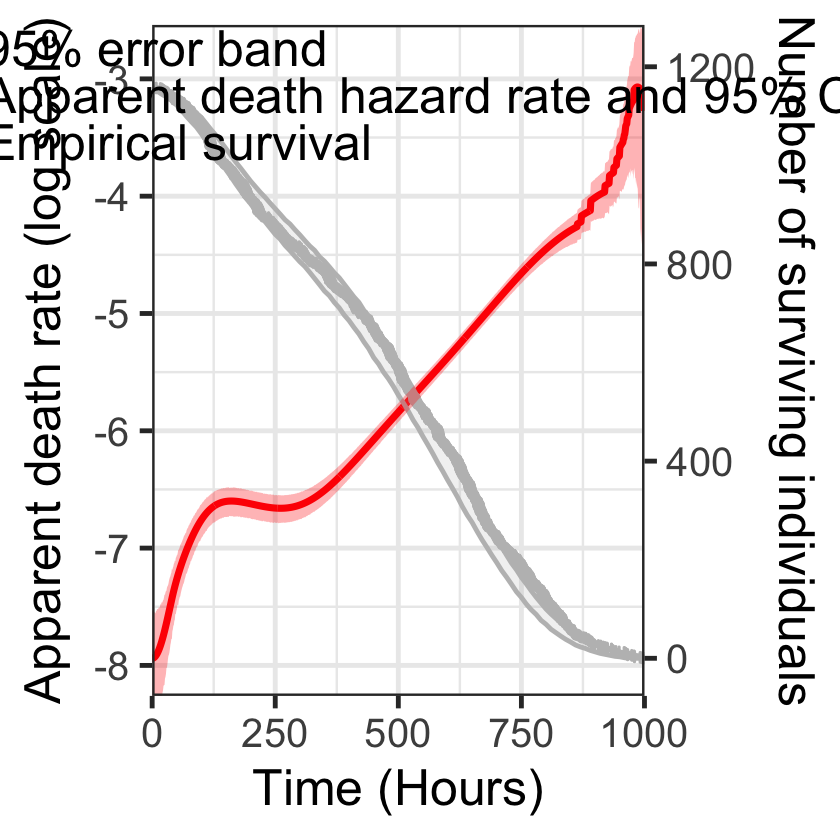

In [59]:
#Figure 2 a)
#apparent death rate plot

#dataframes for plot
data = data.frame(Time = Grid_exp, Hazard = Kopt,inf = CI_infdt, sup = CI_supdt)
data2 = data.frame(surv = (length(TD):0)/length(TD), T = c(0,sort(TD)))
data3 = data.frame(inf = CId[1,]/1159, sup = CId[2,]/1159,time = (1:(length(CI[1,])))*10)
coef = -(min(log(Kopt))-max(log(Kopt)))#rescaling coefficient for plots

#base plot
G_1 <- ggplot() +
scale_y_continuous(
    # Features of the first axis
    # Add a second axis and specify its features
    sec.axis = sec_axis(~.*length(TD)/-(min(log(Kopt))-max(log(Kopt))) - length(TD)*min(log(Kopt))/-(min(log(Kopt))-max(log(Kopt))), 
                        name="Number of surviving individuals")
  ) +theme + scale_x_continuous(expand = c(0,0))


#Plot
G_1 +geom_line(data =data, aes(x=Grid_exp,y= log(Kopt),colour = 'Apparent death hazard rate and 95% CI'),linewidth = 2) +
geom_ribbon(data=data3, aes(x=time,ymin = (inf)*coef+min(log(Kopt)), ymax = (sup)*coef+min(log(Kopt)),
                            colour='95% error band'),fill='grey',alpha=0.2)+
geom_point(data = data2, aes(T, (surv*coef+min(log(Kopt))), colour='Empirical survival'),alpha = 1,shape=3, size = 1)+
geom_ribbon(data = data, aes(x=Time,ymin = inf, ymax = sup,colour = '95% confidence interval'),fill = 'red',alpha=0.3,colour=NA)+
coord_cartesian(xlim=c(0,1000),ylim =  c(-8, -2.8))+
scale_color_manual(name = '', 
                   values = c('Apparent death hazard rate and 95% CI'='red', 'Empirical survival'='grey','95% error band'='grey' ))+
labs(x='Time (Hours)', y='Apparent death rate (log scale)', colour='Legend')+
theme(legend.position = c(0.5, 0.95)) 


ggsave("./Figures/Figure2a.png",  width = 15, height = 10)

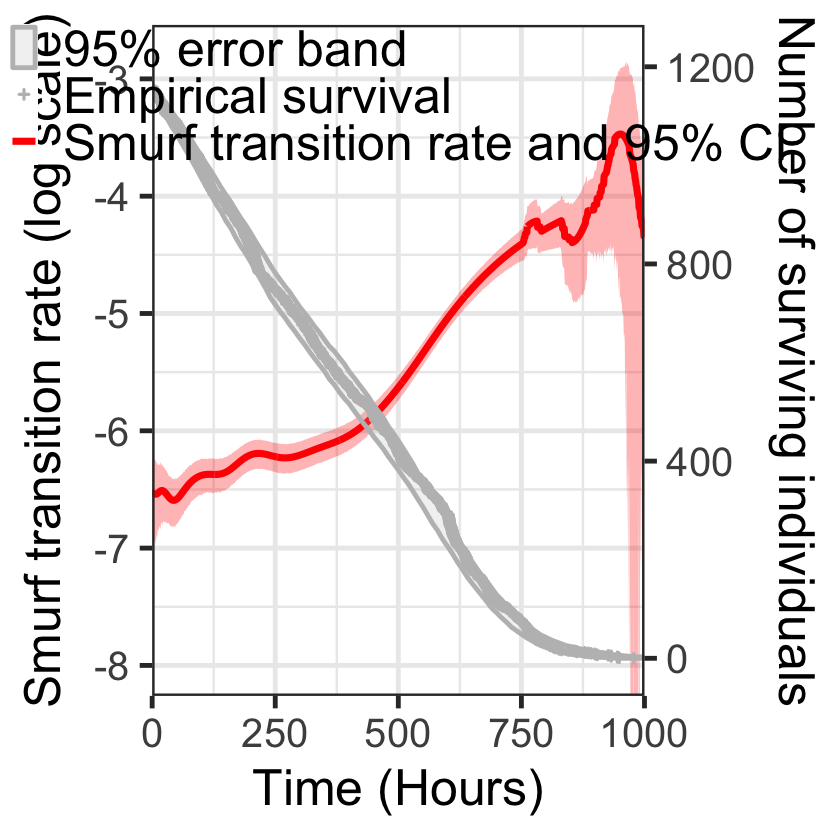

In [60]:
#Figure 2 b)
#Smurf transition rate plot

#dataframes for plot
data = data.frame(Time = Grid_exps, Hazard = Kopts,inf = CI_inf, sup = CI_sup)
data2 = data.frame(surv = (length(TNS):0)/length(TNS), T = c(0,sort(TNS)))
data3 = data.frame(inf = CI[1,]/1159, sup = CI[2,]/1159,time = (1:(length(CI[1,])))*10)


#plots
G_1 + geom_line(data =data, aes(x=Grid_exps,y= log(Kopts),colour = 'Smurf transition rate and 95% CI'),linewidth = 2) +
geom_ribbon( data = data,aes(x=Time,ymin = inf, ymax = sup),fill = 'red',alpha=0.3,colour=NA)+
geom_ribbon(data=data3, aes(x=time,ymin = (inf-min(inf))*coef+min(log(Kopt)), ymax = (sup-min(sup))*coef+min(log(Kopt)),
                            colour='95% error band'),fill='grey',alpha=0.2)+
geom_point(data = data2, aes(T, surv*coef+min(log(Kopt)), colour='Empirical survival'),alpha = 1,shape=3, size = 1)+
scale_color_manual(name = "",
                   values = c('Smurf transition rate and 95% CI'='red', 'Empirical survival'='grey','95% error band'='grey' ))+
coord_cartesian(xlim=c(0,1000),ylim=c(-8,-2.8))+labs(x='Time (Hours)', y ="Smurf transition rate (log scale)", colour='Legend')+
theme(legend.position = c(0.5, 0.95)) 

ggsave(file = "./Figures/Figure2b.png",  width = 12, height = 10) 

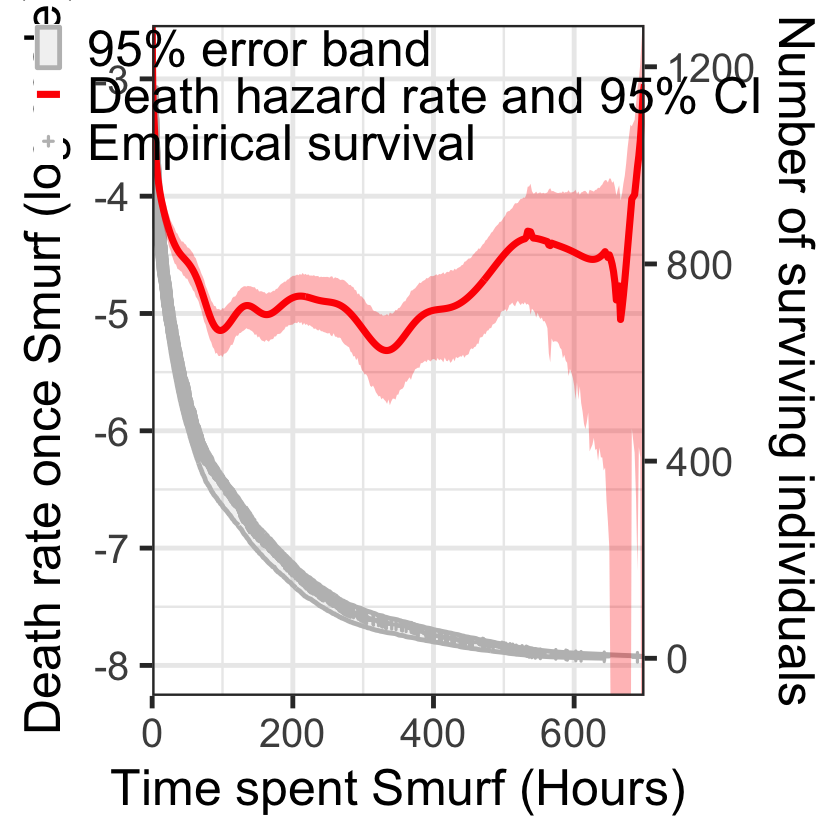

In [61]:
#Figure 2 c)
#Death rate once Smurf plot

#dataframes for plot
data = data.frame(Time = Grid_expd, Hazard = Koptd,inf = CI_infd, sup = CI_supd)
data2 = data.frame(surv = (length(TNS):0)/length(TNS), T = c(0,sort(TS)))
data3 = data.frame(inf = CIS[1,], sup = CIS[2,], time = (length(TNS):1)/length(TNS))

#Plot
G_1 + 
geom_ribbon(data=data3, 
            aes(y=(time-min(time))*coef+min(log(Kopt)),xmax = sup, xmin = inf,colour='95% error band')
            ,fill='grey',alpha=0.2)+
geom_point(data = data2, aes(T, (surv-min(surv))*coef+min(log(Kopt)), colour='Empirical survival'),alpha = 1,shape=3, size = 1)+
geom_line(data =data, aes(x=Grid_expd,y= log(Koptd),colour = 'Death hazard rate and 95% CI'),linewidth = 2) +
geom_ribbon(data = data, aes(x=Time,ymin = inf, ymax = sup,colour = '95% confidence interval'),fill = 'red',alpha=0.3,colour=NA)+
scale_color_manual(name = '', values = c('Death hazard rate and 95% CI'='red', 'Empirical survival'='grey','95% error band'='grey' ))+
labs(x='Time spent Smurf (Hours)', y = 'Death rate once Smurf (log scale)', colour='Legend')+
coord_cartesian(xlim=c(0,700),ylim =  c(-8, -2.8))+
theme(legend.position = c(0.5, 0.95)) 



ggsave(file = "./Figures/Figure2c.png",  width = 12, height = 10) 

### Figure 3

In [5]:
#Non parametric estimation of death hazard rate once Smurf for each quantile of time spent non-Smurf, with global bandwidth choice
print('Quantiles of time spent non-Smurf:')
print(quantile(TNS))#quantiles of time spent non-Smurf

#Q1 estimator
RES1 = minimax_global_data(sort(TS[TNS<=quantile(TNS)[2]]),Grid_expd, B = Bset1) 
Kopt1 = RES1$K #adaptive bandwidth estimator
Bopt1 = RES1$B #chosen global bandwidth
gam_adapt_1  = IBMPopSim::linfun(Grid_expd, Kopt1,0,0) #gamma kernel estimator for simulation
#Q2 estimator 
RES2 = minimax_global_data(sort(TS[quantile(TNS)[3] >= TNS & TNS > quantile(TNS)[2]]),Grid_expd, B = Bset1) 
Kopt2 = RES2$K #adaptive bandwidth estimator
Bopt2 = RES2$B #chosen global bandwidth 
gam_adapt_2  = IBMPopSim::linfun(Grid_expd, Kopt2,0,0) #gamma kernel estimator for simulation
#Q3 estimator
RES3 = minimax_global_data(sort(TS[quantile(TNS)[4] >= TNS & TNS > quantile(TNS)[3]]),Grid_expd, B = Bset1) 
Kopt3 = RES3$K #adaptive bandwidth estimator
Bopt3 = RES3$B #chosen global bandwidth
gam_adapt_3  = IBMPopSim::linfun(Grid_expd, Kopt3,0,0) #gamma kernel estimator for simulation
#Q4 estimator
RES4 = minimax_global_data(sort(TS[TNS > quantile(TNS)[4] ]),Grid_expd, B = Bset1) 
Kopt4 = RES4$K #adaptive bandwidth estimator
Bopt4 = RES4$B #chosen global bandwidth
gam_adapt_4 = IBMPopSim::linfun(Grid_expd, Kopt4,0,0) #gamma kernel estimator for simulation

[1] "Quantiles of time spent non-Smurf:"
          0%          25%          50%          75%         100% 
  0.01539017 185.71346517 374.72054156 601.79021138 978.39538397 


Warning message:
“Removed 158 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 158 rows containing missing values or values outside the scale range
(`geom_line()`).”


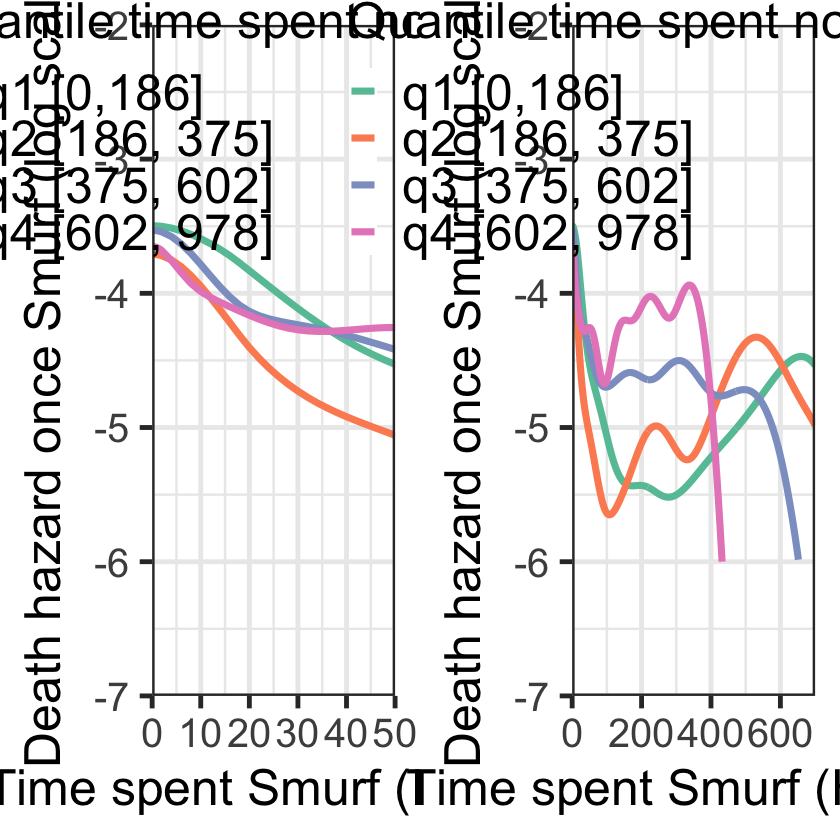

In [62]:
#Figure 3

#removing values of the estimator under a threshold to prevent problems in log scale
Kopt3[Kopt3 <= exp(-6)] <- NA 
Kopt4[Kopt4 <= exp(-6)] <- NA 

#data frame for plot
data2_long <- data.frame(x  = Grid_expd, q1 = Kopt1,q2 = Kopt2, q3 = Kopt3,q4 = Kopt4) |>
  pivot_longer(cols = q1:q4, names_to = "quantile", values_to = "value")

#base plot
 graph <- ggplot(data2_long, aes(x = x, y = log(value), color = quantile)) +
  geom_line(linewidth = 2) +
 theme+
  labs( x = "Time spent Smurf (Hours)",y = "Death hazard once Smurf (log scale)",color = "Quantile time spent non-Smurf") +
  theme(legend.position = c(0.5, 0.85),legend.text = element_text(size = 30),legend.background = element_rect(fill = alpha("white", 0)))+
scale_x_continuous(expand = c(0, 0)) + 
  scale_y_continuous(expand = c(0, 0))+ scale_color_brewer(palette = 'Set2',labels = c(q1 = "q1 [0,186]", q2 = "q2 [186, 375]",
    q3 = "q3 [375, 602]",q4 = "q4 [602, 978]" ))

#Plots
gq1 =  graph+  coord_cartesian(ylim = c(-7, -2),xlim = c(0,50) )
gq2 = graph+  coord_cartesian(ylim = c(-7, -2),xlim = c(0,700) )

gq<-grid.arrange(gq1, gq2, nrow = 1)
gq <- as_ggplot(gq)

ggsave(file = "./Figures/Figure3.png",  width = 20, height = 10) 

# Mechanistic modeling (Section Results 2)
## Smurf transition rate

### Parameter values (Table S3)

In [13]:
#Maximum likelihood coefficient computation for the different tested parametrisations of the Smurf transition rate

#polynomial hazard rate a + bt
a = uniroot(function(x)(der_vrais_poly(x,TNS)[1]) , c(0.6,2)*10^(-8))$root
b = der_vrais_poly(a,TNS)[2]
ci_p = confidence_interval(c(a,b),log_lik_poly,TNS,TS) #95% CI

#Gompertz hazard rate c*exp(dt)
d = uniroot(function(t)(Der_vrais_exp(t,TNS)),c(0.0000005,0.1))$root #max likelihood value of d
c = (N/d+sum(TNS))*d/(sum(TNS*exp(d*TNS))) #max likelihood value of c
ci_g = confidence_interval(c(c,d),log_lik_g,TNS,TS) #95% CI

#Gompertz-Makeham hazard rate f+g*exp(ht)
G_u= param_Gomp_Mak(TNS,0.002,0.02)
f = G_u[1]
g = G_u[2]
h = G_u[3]
ci_gm = confidence_interval(c(f,g,h),log_lik_gm,TNS,TS) #95% CI

#Weibull hazard rate (v/w)*(t/w)^(v-1)
v = weibull.mle(TNS)$shape
w = weibull.mle(TNS)$scale
ci_w = confidence_interval(c(v,w),log_lik_w,TNS,TS) #95% CI

In [14]:
#Table S3
#Printing out parameter values
print(paste('Polynomial', 'a =', a, 'b=' ,  b))
print(paste('Gompertz', 'c =', c, 'd=' ,  d))
print(paste('Gompertz-Makeham', 'f =', f, 'g=' ,  g, 'h=', h))
print(paste('Weibull', 'v =', v, 'w=' ,  w))

[1] "Polynomial a = 6e-09 b= 0.00194263843183802"
[1] "Gompertz c = 0.00101673801443651 d= 0.00286966393137995"
[1] "Gompertz-Makeham f = 0.00146805570484498 g= 7.54476439893396e-05 h= 0.0066373291015625"
[1] "Weibull v = 1.57842928072855 w= 434.396891060271"


### Figure 4

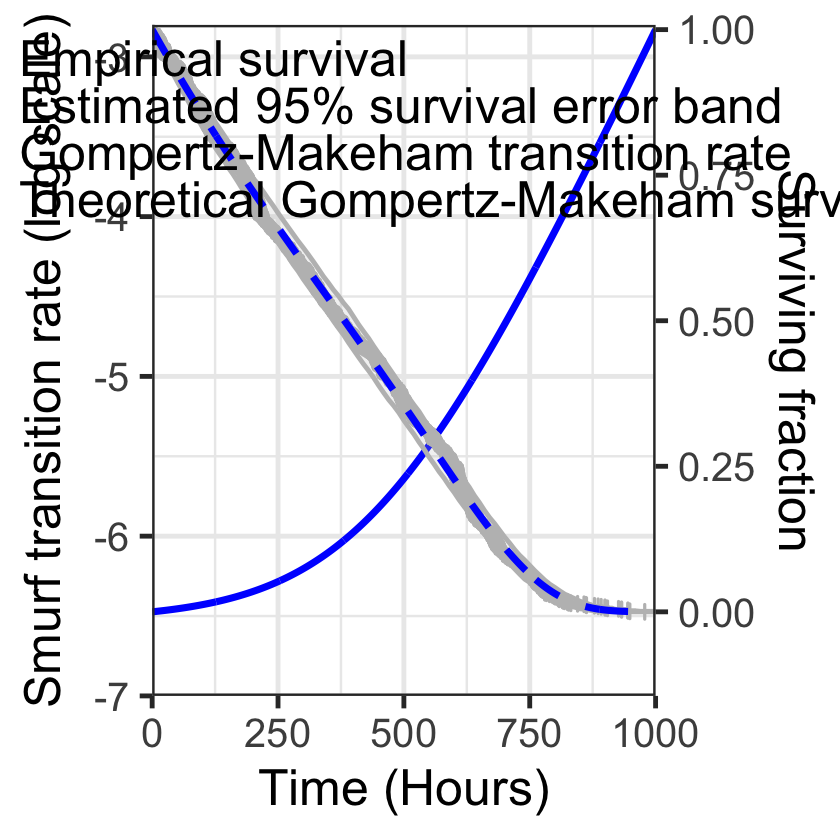

In [63]:
#Figure 4

#Simulating an empirical confidence interval of the survival as non-Smurf for a Gompertz-Makeham Smurf transition rate
simu_death = IBMPopSim::linfun(0:1000, sapply(0:1000,function(c)(1))) #function to simulate death rate, 
#not important as we are only interested in comparing models for time spent non-Smurf now, place holder for the simulation function

CI_surv_gm = NS_CI('gm','np',c(f,g,h), simu_death,sort(TNS),nrep = 500) #simulating empirical confidence interval
                                            
hazard_gm = f+ g*exp(h*(sort(Grid_exps))) #parametric Gompertz-Makeham hazard
surv_gm = exp(-f*Grid_exps - g/h*exp(h*Grid_exps) + g/h) #parametric Gompertz-Makeham survival

#dataframes to plot
data = data.frame(time = Grid_exps, hazard_gm)
data2 = data.frame(surv = length(TNS):0, T = c(0,sort(TNS)))
data3 = data.frame(inf = CI_surv_gm[1,], sup = CI_surv_gm[2,], time = (1:(length(CI_surv_gm[1,])))*10)
coef = (-max(log(hazard_gm)) + min(log(hazard_gm)))/1159 #rescaling coefficient to plot

#Plot
ggplot(data = data)+ 
geom_line(aes(x=time, y = log(hazard_gm),colour = 'Gompertz-Makeham transition rate'),linewidth = 2)+
scale_y_continuous(expand = c(0, 0),
    # Features of the first axis
    name = "Smurf transition rate (log scale)",
    # Add a second axis and specify its features
    sec.axis = sec_axis(~./-(min(log(hazard_gm))-max(log(hazard_gm))) - min(log(hazard_gm))/-(min(log(hazard_gm))-max(log(hazard_gm))), name="Surviving fraction")
  ) +
geom_point(data = data2, aes(T,-surv*coef+min(log(hazard_gm)), colour='Empirical survival'),alpha = 1,shape=3, size = 2)+
geom_ribbon(data=data3, aes(x=time,ymin = -(inf-min(inf))*coef+min(log(hazard_gm)),
                          ymax = -(sup-min(sup))*coef+min(log(hazard_gm)),colour='Estimated 95% survival error band'),fill='grey',alpha=0.2)+
geom_line(aes(x=time, y = -(surv_gm)*coef*1159+min(log(hazard_gm)),colour = 'Theoretical Gompertz-Makeham survival'),linetype = 'dashed',linewidth = 2)+
theme+
scale_color_manual(name = '', values = c('Gompertz-Makeham transition rate' = 'blue', 'Theoretical Gompertz-Makeham survival' = 'blue','Empirical survival'='grey','Estimated 95% survival error band'='grey'))+
labs(x='Time (Hours)',y = 'Smurf hazard')+coord_cartesian( ylim = c(-7, -2.8),xlim=c(0,1000))+
scale_x_continuous(expand = c(0, 0))+  theme(legend.position = c(0.5, 0.9),legend.key.width = unit(5, "line")) 

ggsave(file = "./Figures/Figure4.png",  width = 15, height = 10) 


## Death Hazard rate once smurf

### Parameter values (Table S4)

In [16]:
#Computing maximum likelihood coefficients for all models 

#Model 1 constant rate
kDi_int =  const_ML_kd(TS)
kDi = kDi_int[1] #parameter value
kD_ci = kDi_int[2] #95% CI

#Model 2 piecewise constant rate kD1i*(t<= 24) + kD2i*(t> 24)
coef_i = two_const_indep(TS) 
kD1i = coef_i[1] #first 24 hours
kD2i = coef_i[2] #after 24 hours
kD1_ci = coef_i[3] #95% CI
kD2_ci = coef_i[4] #95% CI

#Model 3 decreasing exponential rate kD1ei+ kD2ei*exp(d_ei*t)
A = 0.01+ (0.1-0.01)*(1:1000)/1000
gomp_D = g_m_death(TS, A, 1/3500, 100/3500)
kD1ei = gomp_D[1] 
kD2ei = gomp_D[2]
d_ei = gomp_D[5]
ci_e = confidence_interval(c(kD1ei,kD2ei,d_ei),log_lik_gm_d,TNS,TS) #95% CI


#Cox coefficient and mean
lim=200
#Models 4 to 6
gam = cox_coef(TNS,TS) #Cox coefficient for all times spent non-Smurf
m = mean(TNS) #mean to rescale time spent non-Smurf

#Models 7 to 12
TNS_aux = (TNS- mean(TNS[TNS>=lim])) *(TNS>=lim) #auxiliary array with 0 under lim and mean 0

cox_sup = coxph(Surv(TS,rep(1,length(TS)))~TNS_aux)
gam_sup = cox_sup$coefficients #cox coef on TNS >= lim
m_sup = mean(TNS[TNS >lim]) #mean to rescale time spent non-Smurf over 200 hours

#Parameters for base hazard
#Model 4 constant + dependence
kD_4= const_ML_kd_dep(TS,TNS,gam) 

#Model 7 constant + piecewise dependence
kD_7= const_ML_kd_piec(TS,TNS,lim,gam_sup) 

#Model 10 constant + piecewise dependence + 2 base hazards
#Strata 1 for TNS <= lim
kD_10_s1= const_ML_kd(TS[TNS<lim])[1] 
#Strata 2 for TNS > lim
kD_10_s2  = const_ML_kd_dep(TS[TNS>lim],TNS[TNS>lim],gam_sup) 

#Model 5 piecewise constant + dependence 
coef_d = two_const_dep(TNS,TS,gam) 
kD1_5 = coef_d[1]
kD2_5= coef_d[2]

#Model 8 piecewise constant + piecewise dependence
kD1_8 = two_const_piec(TNS,TS,200,gam_sup)[1] #2dep 
kD2_8 = two_const_piec(TNS,TS,200,gam_sup)[2]#2dep

#Model 11 piecewise costant + piecewise dependence + 2 base hazards 
#Strata 1 for TNS <= lim
coef_t1 = two_const_indep(TS[TNS<=lim]) 
kD1_11_s1 = coef_t1[1]
kD2_11_s1= coef_t1[2]
#Strata 2 for TNS > lim
coef_t2 = two_const_dep(TNS[TNS>lim],TS[TNS>lim],gam_sup) 
kD1_11_s2= coef_t2[1]
kD2_11_s2= coef_t2[2]

#Model 6 decreasing exponential + dependence
param_gm_6 = max_lik_gomp_mak_D(TS,TNS,'6',gam,0, 1/1700,120/1700,0.008,0.09) #we input the minimum and maximum between which we search for d
kD1e_6 = param_gm_6[1]
kD2e_6 = param_gm_6[2]
d_6 = param_gm_6[3]
ci_e6 = confidence_interval(c(kD1e_6,kD2e_6,d_6),log_lik_gm_d,TNS,TS*exp(gam*(TNS-m)))#95% CI

#Model 9 decreasing exponential + piecewise dependence
param_gm_9 = max_lik_gomp_mak_D(TS,TNS,'9',gam_sup,lim,1/1700,120/1700,0.008,0.1)
kD1e_9 = param_gm_9[1]
kD2e_9 = param_gm_9[2]
d_9 = param_gm_9[3]
ci_e9 = confidence_interval(c(kD1e_9,kD2e_9,d_9),log_lik_gm_d,TNS,TS*exp((TNS>=200)*gam_sup*(TNS-m_sup)))#95% CI

#Model 12 decreasing exponential + piecewise dependence + 2 base hazards
#Strata 1 for TNS <= lim
param_gm_12_s1 = max_lik_gomp_mak_D(TS[TNS<=lim],TNS[TNS<=lim],'12_s1',0,lim,1/1700,120/1700,0.008,0.15)
kD1e_12_s1 = param_gm_12_s1[1]
kD2e_12_s1 = param_gm_12_s1[2]
d_12_s1 = param_gm_12_s1[3]
ci_e12_s1 = confidence_interval(c(kD1e_12_s1,kD2e_12_s1,d_12_s1),log_lik_gm_d,TNS*(TNS<200),TS*(TNS<200)) #95% CI

#Strata 2 for TNS > lim
param_gm_12_s2 = max_lik_gomp_mak_D(TS[TNS>lim],TNS[TNS>lim],'12_s2',gam_sup,lim,1/1700,120/1700,0.007,0.5)
kD1e_12_s2 = param_gm_12_s2[1]
kD2e_12_s2 = param_gm_12_s2[2]
d_12_s2 = param_gm_12_s2[3]
ci_e12_s2 = confidence_interval(c(kD1e_12_s2,kD2e_12_s2,d_12_s2),log_lik_gm_d,TNS*(TNS>=200),TS*exp((TNS>=200)*gam_sup*(TNS-m_sup)))#95% CI


In [17]:
print('Base hazards:')
print(paste('Model 1: ','k=', kDi))
print(paste('Model 2: ','k1=', kD1i, 'k2=', kD2i ))
print(paste('Model 3: ','k1=', kD1ei, 'k2=', kD2ei,'d=',d_ei ))
print(paste('Model 4: ','k=', kD_4))
print(paste('Model 5: ','k1=', kD1_5, 'k2=', kD2_5 ))
print(paste('Model 6: ','k1=', kD1e_6, 'k2=', kD2e_6,'d=',d_6 ))
print(paste('Model 7: ','k=', kD_7))
print(paste('Model 8: ','k1=', kD1_8, 'k2=', kD2_8 ))
print(paste('Model 9: ','k1=', kD1e_9, 'k2=', kD2e_9,'d=',d_9 ))
print(paste('Model 10: ','k1=', kD_10_s1, 'k2=', kD_10_s2))
print(paste('Model 11: ','k11=', kD1_11_s1, 'k12=', kD2_11_s1, 'k21=', kD1_11_s2, 'k22=', kD2_11_s2 ))
print(paste('Model 12: ','k11=', kD1e_12_s1, 'k12=', kD2e_12_s1, 'd1=', d_12_s1, 'k21=', kD1e_12_s2, 'k22=', kD2e_12_s2, 'd2=', d_12_s1 ))

print('Dependence:')
print(paste('Models 4,5,6:', 'gamma=', gam, 'mu =', m))
print(paste('Models 7 to 12:', 'gamma=', gam_sup, 'mu =', m_sup))


[1] "Base hazards:"
[1] "Model 1:  k= 0.0107735946470428"
[1] "Model 2:  k1= 0.0222095362100574 k2= 0.00804687564923696"
[1] "Model 3:  k1= 0.0073127348748547 k2= 0.0293175232889041 d= 0.06715"
[1] "Model 4:  k= 0.0110469154328489"
[1] "Model 5:  k1= 0.0218373438515362 k2= 0.00832880511818416"
[1] "Model 6:  k1= 0.00775272812716795 k2= 0.0311081941797445 d= 0.078766"
[1] "Model 7:  k= 0.0111943111852753"
[1] "Model 8:  k1= 0.0218018496062704 k2= 0.00847192904707506"
[1] "Model 9:  k1= 0.00789868339838357 k2= 0.0313019040373375 d= 0.080128"
[1] "Model 10:  k1= 0.0102457840625678 k2= 0.0116095680907354"
[1] "Model 11:  k11= 0.02931931865839 k12= 0.00637296632554651 k21= 0.0193588111376838 k22= 0.00943924993601543"
[1] "Model 12:  k11= 0.00519526271428511 k12= 0.03617395992139 d1= 0.046766 k21= 0.00984662492429677 k22= 0.0522740581049522 d2= 0.046766"
[1] "Dependence:"
[1] "Models 4,5,6: gamma= 0.000733200521778072 mu = 387.377342129682"
[1] "Models 7 to 12: gamma= 0.00132763650860993 mu 

### Tables 2 and 3

In [18]:
#Data for Tables 2 and 3

#Quantitative comparison of laws of time spent Smurf for time spent non-Smurf above and under 200 hours
Xinf = TS[TNS<=lim]
Xsup = TS[TNS>lim]

print(paste('Correlation on TNS >', lim,':',cor_lim_sup(lim,TNS,TS) )) 
print(paste('Correlation on TNS <= ', lim,':', cor_lim_inf(lim,TNS,TS)) )
print(paste('Mean time spent Smurf on TNS <= lim:', mean(Xinf)) )
print(paste('Mean time spent Smurf on TNS >lim:',mean(Xsup)) )
print(paste('SD of time spent Smurf on TNS <= lim:',sqrt(var(Xinf)))) 
print(paste('SD of spent Smurf on TNS > lim:',sqrt(var(Xsup)))) 
print(paste('log p-value for Wald test of independence on TNS <= lim:',score_dep_inf(lim,TNS,TS))) 
print(paste('log p-value for Wald test of independence on TNS > lim:',score_dep_sup(lim,TNS,TS))) 

[1] "Correlation on TNS > 200 : -0.280946681395569"
[1] "Correlation on TNS <=  200 : -0.0766483852450766"
[1] "Mean time spent Smurf on TNS <= lim: 97.6011200210065"
[1] "Mean time spent Smurf on TNS >lim: 90.9720985793678"
[1] "SD of time spent Smurf on TNS <= lim: 149.65297867027"
[1] "SD of spent Smurf on TNS > lim: 112.082952912928"
[1] "log p-value for Wald test of independence on TNS <= lim: -3.13661856658848"
[1] "log p-value for Wald test of independence on TNS > lim: -35.638188281009"


### Table 1

In [55]:
#Values for Table 1
#Comparing models for death hazard rate once Smurf with BIC

print(paste('Model 1',BIC(TS,TNS,function(t,y)(haz_c_i(t,y,kDi)),3)))
print(paste('Model 2',BIC(TS,TNS,function(t,y)(haz_2c_i(t,y,kD1i,kD2i)),4)))
print(paste('Model 3',BIC(TS,TNS,function(t,y)(haz_e_i(t,y,kD1ei,kD2ei, d_ei)),5)))

print(paste('Model 4', BIC(TS,TNS,function(t,y)(haz_c_d(t,y,gam,m,kD_4)),3)))
print(paste('Model 5',BIC(TS,TNS,function(t,y)(haz_2c_d(t,y,gam,m,kD1_5,kD2_5)),4)))
print(paste('Model 6',BIC(TS,TNS,function(t,y)(haz_e_d(t,y,gam,m,kD1e_6, kD2e_6,d_6)),5)))

print(paste('Model 7',BIC(TS,TNS,function(t,y)(haz_c_2d(t,y,gam_sup,m_sup,lim,kD_7)),3)))
print(paste('Model 8',BIC(TS,TNS,function(t,y)(haz_2c_2d(t,y,gam_sup,m_sup,lim,kD1_8,kD2_8)),4)))
print(paste('Model 9',BIC(TS,TNS,function(t,y)(haz_e_2d(t,y,gam_sup,m_sup,lim,kD1e_9, kD2e_9,d_9)),5)))

print(paste('Model 10',BIC(TS,TNS,function(t,y)(haz_dep_strat_c(t,y,gam_sup,m_sup,lim,kD_10_s1,kD_10_s2)),6)))
print(paste('Model 11',BIC(TS,TNS,function(t,y)(haz_dep_strat_2c(t,y,gam_sup,m_sup,lim,kD1_11_s1, kD2_11_s1,kD1_11_s2, kD2_11_s2)),6)))
print(paste('Model 12',BIC(TS,TNS,function(t,y)(haz_dep_strat_e(t,y,gam_sup,m_sup,lim,kD1e_12_s1, kD2e_12_s1,d_12_s1,kD1e_12_s2, kD2e_12_s2,d_12_s2)),8)))


[1] "Model 1 12841.2290469271"
[1] "Model 2 12590.8938261018"
[1] "Model 3 12510.3390075418"
[1] "Model 4 12783.1560947557"
[1] "Model 5 12558.1093886469"
[1] "Model 6 12482.8084092127"
[1] "Model 7 12752.4322176997"
[1] "Model 8 12535.7859323367"
[1] "Model 9 12463.1065054486"
[1] "Model 10 12787.6822487498"
[1] "Model 11 12512.9585845884"
[1] "Model 12 12431.0635395842"


In [58]:
#Values for Table 1
#Comparing models for death hazard rate once Smurf with Wasserstein distance

##can be long as 100 populations are simulated for each computation of the Wasserstein distance
was_c_d = emp_wasserstein('gm',4,TNS,TS,c(f,g,h),c(kD_4,gam,m))
was_2c_d = emp_wasserstein('gm',5,TNS,TS,c(f,g,h),c(kD1_5,kD2_5,gam,m))
was_e_d = emp_wasserstein('gm',6,TNS,TS,c(f,g,h),c(kD1e_6,kD2e_6,d_6,gam,m))

was_c_2d = emp_wasserstein('gm',7,TNS,TS,c(f,g,h),c(kD_7,gam_sup,m_sup,lim))
was_2c_2d = emp_wasserstein('gm',8,TNS,TS,c(f,g,h),c(kD1_8, kD2_8,gam_sup,m_sup,lim))
was_e_2d = emp_wasserstein('gm',9,TNS,TS,c(f,g,h),c(kD1e_9, kD2e_9,d_9,gam_sup,m_sup,lim))

was_c_2ds = emp_wasserstein('gm',10,TNS,TS,c(f,g,h),c(kD_10_s1,kD_10_s2 ,gam_sup,m_sup,lim))
was_2c_2ds = emp_wasserstein('gm',11,TNS,TS,c(f,g,h),c(kD1_11_s1, kD2_11_s1,kD1_11_s2, kD2_11_s2,gam_sup,m_sup,lim))
was_e_2ds = emp_wasserstein('gm',12,TNS,TS,c(f,g,h),c(kD1e_12_s1, kD2e_12_s1,d_12_s1,kD1e_12_s2, kD2e_12_s2,d_12_s2,gam_sup,m_sup,lim))

print(paste('Model 4 Wasserstein distance',was_c_d[1], 'Standard deviation',was_c_d[2]))
print(paste('Model 5 Wasserstein distance',was_2c_d[1], 'Standard deviation',was_2c_d[2]))
print(paste('Model 6 Wasserstein distance',was_e_d[1], 'Standard deviation',was_e_d[2]))

print(paste('Model 7 Wasserstein distance',was_c_2d[1], 'Standard deviation',was_c_2d[2]))
print(paste('Model 8 Wasserstein distance',was_2c_2d[1], 'Standard deviation',was_2c_2d[2]))
print(paste('Model 9 Wasserstein distance',was_e_2d[1], 'Standard deviation',was_e_2d[2]))

print(paste('Model 10 Wasserstein distance',was_c_2ds[1], 'Standard deviation',was_c_2ds[2]))
print(paste('Model 11 Wasserstein distance',was_2c_2ds[1], 'Standard deviation',was_2c_2ds[2]))
print(paste('Model 12 Wasserstein distance',was_e_2ds[1], 'Standard deviation',was_e_2ds[2]))

[1] "Model 4 Wasserstein distance 33.0348468169962 Standard deviation 2.21388497318138"
[1] "Model 5 Wasserstein distance 25.4913663149618 Standard deviation 1.86805812853751"
[1] "Model 6 Wasserstein distance 25.5190418126981 Standard deviation 1.94415106388394"
[1] "Model 7 Wasserstein distance 31.7263784057945 Standard deviation 1.87076171103359"
[1] "Model 8 Wasserstein distance 25.1270736888667 Standard deviation 2.14249301305146"
[1] "Model 9 Wasserstein distance 24.4395662265383 Standard deviation 2.22846170130904"
[1] "Model 10 Wasserstein distance 31.7946017248529 Standard deviation 2.08237423678696"
[1] "Model 11 Wasserstein distance 23.2074298788753 Standard deviation 2.14052450884965"
[1] "Model 12 Wasserstein distance 23.0373753245846 Standard deviation 2.36950450028352"


### Figure 5

Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”
Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”


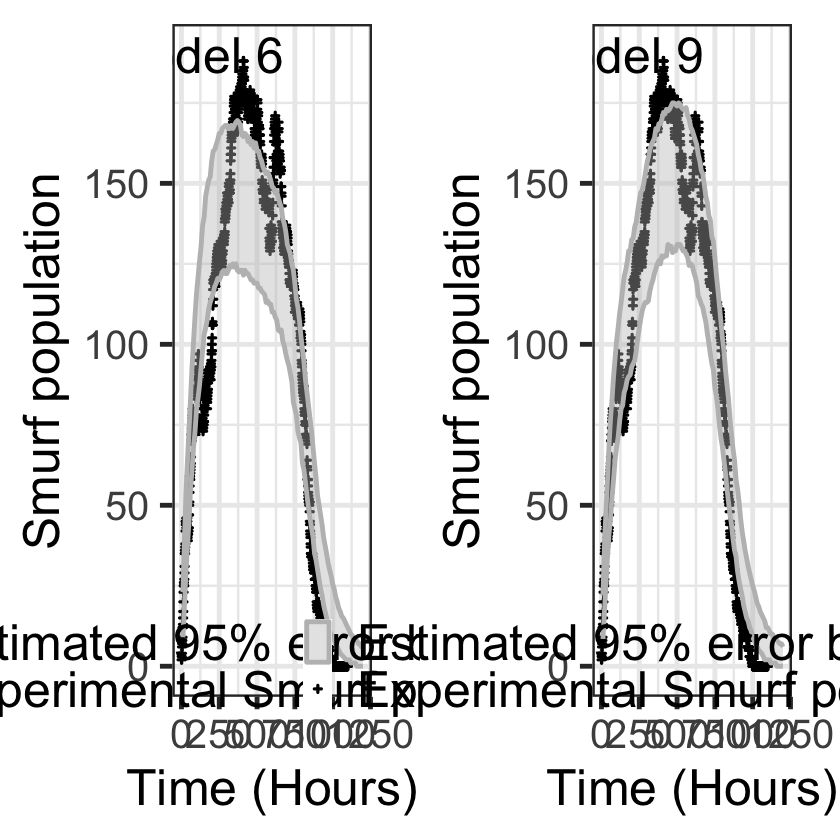

In [64]:
#Figure 5
#Estimated pointwise 95% confidence intervals for Smurf population over time for models 6 and 9

#Model 6
CIs6 = smurf_CI('gm', 6, c(f,g,h), c(kD1e_6, kD2e_6,d_6,gam,m), smurf_exp,nrep=500)

#Model 9
CIs9 = smurf_CI('gm', 9, c(f,g,h), c(kD1e_9, kD2e_9,d_9,gam_sup,m_sup,lim), smurf_exp,nrep=500)

#dataframe to plot
data = data.frame(time = (1:149)*10,inf6 = CIs6[1,], sup6 =  CIs6[2,],inf9 = CIs9[1,], sup9 =  CIs9[2,])
data2 = data.frame( th = smurf_exp, time = 1:1100)

#Plots
#base plot 
G_base <- ggplot() +geom_point(data = data2, aes(time, smurf_exp, colour='Experimental Smurf population'),alpha = 1,shape=3,size = 0.5)+
theme+ theme(legend.position = c(0.4,0.1))+ scale_color_manual(name = '', values = c('Experimental Smurf population'='black','Estimated 95% error band'='grey' ))+
xlim(0,1200)+labs(x='Time (Hours)', colour='Legend', y = 'Smurf population')+theme(plot.margin = unit(c(1, 2, 1, 1), "lines"))


G6 <- G_base + geom_ribbon(data=data, aes(x=time,ymin = inf6, ymax = sup6,colour='Estimated 95% error band'),fill='grey',alpha=0.4)+
annotate("text", x=90, y=190, label= 'Model 6') 

G9 <- G_base + geom_ribbon(data=data, aes(x=time,ymin = inf9, ymax = sup9,colour='Estimated 95% error band'),fill='grey',alpha=0.4)+
annotate("text", x=90, y=190, label= 'Model 9') 

G_mod <-grid.arrange(G6, G9, nrow = 1)
G_mod <- as_ggplot(G_mod)
ggsave(file = "./Figures/Figure5.png",  width = 20, height = 10) 


### Figure 6

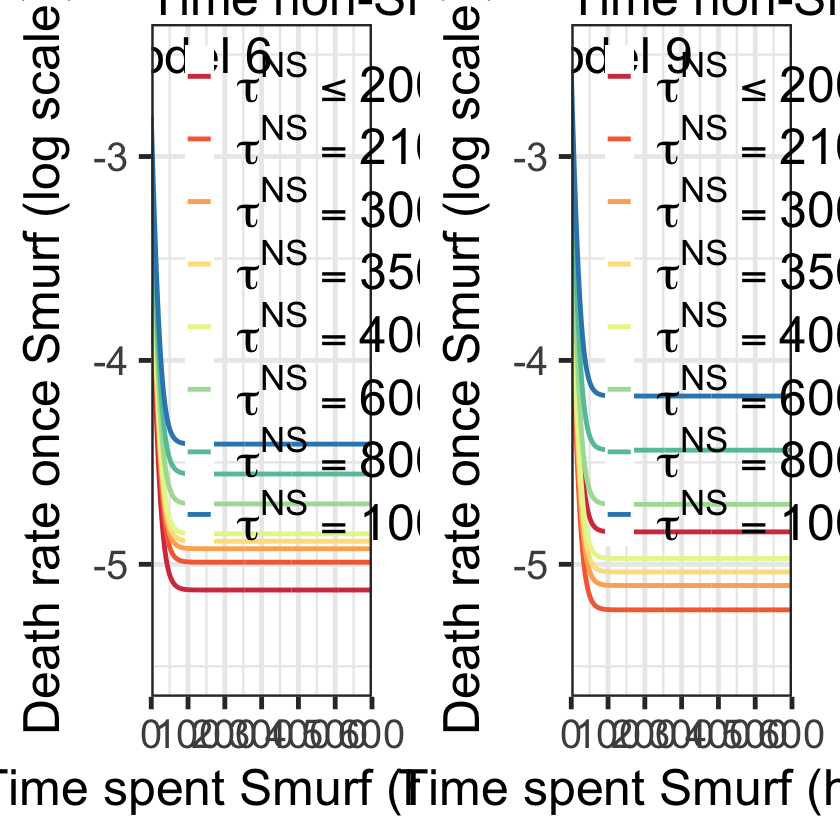

In [65]:
#Figure 6
#Plot of death hazard rates for different times spent non-Smurf in models 6 and 9 

Time = 0:600 #array for time spent Smurf
Ys = c(24,210,300,350,400,600,800,1000) #different values of time spent non-Smurf
haz_dep1_aux = function(x,y)(haz_e_d(x,y,gam,m,kD1e_6, kD2e_6,d_6)) #auxiliary function to compute death hazard rates for model 6
haz_dep_aux = function(x,y)(haz_e_2d(x,y,gam_sup,m_sup,lim,kD1e_9, kD2e_9,d_9)) #auxiliary function to compute death hazard rates for model 9

#Data frames to plot
data6 = data.frame(Time, haza = sapply(1:length(Ys), function(i)(log(sapply(Time, function(x)(haz_dep1_aux(x,Ys[i])))))))
data9 = data.frame(Time, haza = sapply(1:length(Ys), function(i)(log(sapply(Time, function(x)(haz_dep_aux(x,Ys[i])))))))                                                                  
data_long6 <- data6 %>% pivot_longer(  cols = starts_with("haza"), names_to = "key", values_to = "value")
data_long9 <- data9 %>% pivot_longer( cols = starts_with("haza"),names_to = "key", values_to = "value")       
                                                                 
#base plot
G <- ggplot() +theme_bw(base_size = 20)  +                                                 
labs(y ='Death rate once Smurf (log scale)',x='Time spent Smurf (hours)')+
 scale_color_brewer(palette = 'Spectral',name = 'Time non-Smurf',  labels = c(
      "haza.1" = TeX('$\\tau^{NS} \\leq 200 $'),
      "haza.2" = TeX('$\\tau^{NS} = 210 $'),
      "haza.3" = TeX('$\\tau^{NS} = 300 $'),
      "haza.4" = TeX('$\\tau^{NS} = 350 $'),
      "haza.5" = TeX('$\\tau^{NS} = 400 $'),
      "haza.6" = TeX('$\\tau^{NS} = 600 $'),
      "haza.7" = TeX('$\\tau^{NS} = 800 $'),
      "haza.8" = TeX('$\\tau^{NS} = 1000 $')
    ))+
                                                                        
  guides(
    colour = guide_legend(
      override.aes = list(size = 2), title.position = "top", title.hjust = 0.5  ))+
 theme + theme(legend.position = c(0.8, 0.65),plot.margin = unit(c(1, 2, 1, 1), "lines"))+scale_x_continuous(expand = c(0, 0)) +
  coord_cartesian( ylim = c(-5.5, -2.5)   )                                                                       

                                                                           
#plots
G9h <- G + geom_line(data = data_long9,aes(x=Time, y=value,colour = key)) +annotate("text", x=90, y=-2.5, label= 'Model 9') 
                                                                   

G6h <- G + geom_line(data = data_long6,aes(x=Time, y=value,colour = key))  + annotate("text", x=90, y=-2.5, label= 'Model 6') 
     

G_modh <-grid.arrange(G6h, G9h, nrow = 1)
G_modh <- as_ggplot(G_modh)
ggsave(file = "./Figures/Figure6.png",  width = 20, height = 10) 

                                                                            

### Table 3

In [36]:
#Values for Table 3
#Theoretical means, variances etc for model 6

to_int3 = function(y)(df_ks(y,f,g,h)) #to compute integrals on time spent non-Smurf
    
#auxiliary functions for integration
to_int6 = function(x,y)(x*df_ks(y,f,g,h)*df_kd_dep_e(x+y,y,gam,m,kD1e_6, kD2e_6,d_6)) #to compute mean time spent Smurf
to_int6t = function(x,y)(x*df_ks(y,f,g,h)*df_kd_dep_e(x,y,gam,m,kD1e_6, kD2e_6,d_6)) #to compute mean lifetime
to_int_aux6 = Vectorize(function(x)(integrate(function(y)(to_int6t(x,y)),0,x)$value)) 
to_int_aux61 = Vectorize(function(x)(integrate(function(y)(to_int6t(x,y)),0,min(x,200))$value))
to_int_aux62 = Vectorize(function(x)(integrate(function(y)(to_int6t(x,y)),200,max(x,200))$value))                                
to_int_aux6_v = Vectorize(function(x)(x*integrate(function(y)(to_int6t(x,y)),0,x)$value))
to_int_aux62_v = Vectorize(function(x)(x*integrate(function(y)(to_int6t(x,y)),200,max(x,200))$value))
to_int_aux61_v = Vectorize(function(x)(x*integrate(function(y)(to_int6t(x,y)),0,min(x,200))$value))
var16 = function(x,y)(x^2*df_ks(y,f,g,h)*df_kd_dep_e(x+y,y,gam,m,kD1e_6, kD2e_6,d_6)) #to compute variance time spent Smurf
       
#means computations
mean_S6 =integral2(to_int6, 0, 100000, 0, 100000)$Q
mean_d6 = integrate(to_int_aux6, 0, 100000)$value
mean_S16 =integral2(to_int6, 0, 100000, 0, 200)$Q/(integrate(to_int3, 0, 200)$value)
mean_S26 =integral2(to_int6, 0, 100000, 200, 100000)$Q/(integrate(to_int3, 200, 100000)$value)
mean_dS16 = integrate(to_int_aux61,0,100000)$value/(integrate(to_int3, 0, 200)$value)
mean_dS26 = integrate(to_int_aux62,200,100000)$value/(integrate(to_int3, 200, 100000)$value)
                                                  
#variances computations 
var_s6 = integral2(var16, 0, 100000, 0, 100000)$Q- mean_S6^2
var_d6 = integrate(to_int_aux6_v,0,100000)$value  - mean_d6^2
var_s16 = integral2(var16, 0, 100000, 0, 200)$Q/(integrate(to_int3, 0, 200)$value)- mean_S16^2
var_s26 = integral2(var16, 0, 100000, 200,100000)$Q/(integrate(to_int3, 200, 100000)$value)- mean_S26^2
var_dS16 = integrate(to_int_aux61_v,0,100000)$value/(integrate(to_int3, 0, 200)$value) - mean_dS16^2
var_dS26 = integrate(to_int_aux62_v,200,10000)$value/(integrate(to_int3, 200, 100000)$value) - mean_dS26^2        

In [37]:
#Values for Table 3
#Theoretical means, variances etc for model 9

#auxiliary functions for integration
to_int9 = function(x,y)(x*df_ks(y,f,g,h)*df_kd_2dep_cont(x+y,y,gam_sup,m_sup,lim,kD1e_9, kD2e_9,d_9))#to compute mean time spent Smurf
to_int9t = function(x,y)(x*df_ks(y,f,g,h)*df_kd_2dep_cont(x,y,gam_sup,m_sup,lim,kD1e_9, kD2e_9,d_9))#to compute mean lifetime
to_int_aux9 = Vectorize(function(x)(integrate(function(y)(to_int9t(x,y)),0,min(x,200))$value))
to_int_aux92 = Vectorize(function(x)(integrate(function(y)(to_int9t(x,y)),200,max(x,200))$value))
to_int_aux9_v = Vectorize(function(x)(x*integrate(function(y)(to_int9t(x,y)),0,min(x,200))$value))
to_int_aux92_v = Vectorize(function(x)(x*integrate(function(y)(to_int9t(x,y)),200,max(x,200))$value))                                         
var19 = function(x,y)(x^2*df_ks(y,f,g,h)*df_kd_2dep_cont(x+y,y,gam_sup,m_sup,lim,kD1e_9, kD2e_9,d_9))#to compute variance time spent Smurf
       
#means computations
mean_S9 =integral2(to_int9, 0, 100000, 0, 100000)$Q
mean_S19 =integral2(to_int9, 0, 100000, 0, 200)$Q/(integrate(to_int3, 0, 200)$value)
mean_S29 =integral2(to_int9, 0, 100000, 200, 100000)$Q/(integrate(to_int3, 200, 100000)$value)
mean_dS19 = integrate(to_int_aux9,0,100000)$value/(integrate(to_int3, 0, 200)$value)
mean_dS29 = integrate(to_int_aux92,200,100000)$value/(integrate(to_int3, 200, 100000)$value)
mean_d9 = mean_dS19*(integrate(to_int3, 0, 200)$value) + mean_dS29*integrate(to_int3, 200, 100000)$value

#variances computations
var_s9 = integral2(var19, 0, 100000, 0, 100000)$Q- mean_S9^2
var_s19 = integral2(var19, 0, 100000, 0, 200)$Q/(integrate(to_int3, 0, 200)$value)- mean_S19^2
var_s29 = integral2(var19, 0, 100000, 200,100000)$Q/(integrate(to_int3, 200, 100000)$value)- mean_S29^2
var_dS19 = integrate(to_int_aux9_v,0,100000)$value/(integrate(to_int3, 0, 200)$value) - mean_dS19^2
var_dS29 = integrate(to_int_aux92_v,200,100000)$value/(integrate(to_int3, 200, 100000)$value) - mean_dS29^2
var_d9 = integrate(to_int_aux9_v,0,100000)$value + integrate(to_int_aux92_v,200,100000)$value - mean_d9^2

In [39]:
#Table 3
#Printing out the results 

print('Data')
cat('\n')
print(paste('Experimental time spent smurf:', mean(TS), 'sd',sqrt(var(TS))))
print(paste('Experimental time spent non-smurf:', mean(TNS),'sd',sqrt(var(TNS))))
print(paste('Experimental time spent smurf strata 1:', mean(TS[TNS <=200]), 'sd', sqrt(var(TS[TNS<=200]))))
print(paste('Experimental time spent smurf strata 2:', mean(TS[TNS >200]), 'sd', sqrt(var(TS[TNS>200]))))
print(paste('Experimental lifetime :', mean(TD), 'sd',sqrt(var(TD))))
print(paste('Experimental lifetime strata 1:', mean(TD[TNS<=200]), 'sd',sqrt(var(TD[TNS<=200]))))
print(paste('Experimental lifetime strata 2:', mean(TD[TNS>200]), 'sd',sqrt(var(TD[TNS>200]))))
cat('\n')

print('Model 6')
cat('\n')
print(paste('Theoretical time spent smurf:', mean_S6, 'sd',sqrt(var_s6) ))
print(paste('Theoretical time spent smurf strata 1:', mean_S16, 'sd',sqrt(var_s16) ))
print(paste('Theoretical time spent smurf strata 2:', mean_S26, 'sd',sqrt(var_s26) ))
print(paste('Theoretical lifetime :', mean_d6, 'sd',sqrt(var_d6) ))
print(paste('Theoretical lifetime strata 1:', mean_dS16, 'sd',sqrt(var_dS16) ))
print(paste('Theoretical lifetime strata 2:', mean_dS26, 'sd',sqrt(var_dS26) ))
cat('\n')
                                                  
print('Model 9')
cat('\n')
print(paste('Theoretical time spent smurf:', mean_S9, 'sd',sqrt(var_s9) ))
print(paste('Theoretical time spent smurf strata 1:', mean_S19, 'sd',sqrt(var_s19) ))
print(paste('Theoretical time spent smurf strata 2:', mean_S29, 'sd',sqrt(var_s29) ))
print(paste('Theoretical lifetime :', mean_d9, 'sd',sqrt(var_d9) ))
print(paste('Theoretical lifetime strata 1:', mean_dS19, 'sd',sqrt(var_dS19) ))
print(paste('Theoretical lifetime strata 2:', mean_dS29, 'sd',sqrt(var_dS29) ))




[1] "Data"

[1] "Experimental time spent smurf: 92.819530784415 sd 123.672627593653"
[1] "Experimental time spent non-smurf: 387.377342129682 sd 237.285499040681"
[1] "Experimental time spent smurf strata 1: 97.6011200210065 sd 149.65297867027"
[1] "Experimental time spent smurf strata 2: 90.9720985793678 sd 112.082952912928"
[1] "Experimental lifetime : 480.196872914097 sd 248.899390220886"
[1] "Experimental lifetime strata 1: 198.417345212122 sd 156.550519637506"
[1] "Experimental lifetime strata 2: 589.066235889859 sd 184.074727490427"

[1] "Model 6"

[1] "Theoretical time spent smurf: 92.4835037605228 sd 125.595536993438"
[1] "Theoretical time spent smurf strata 1: 134.14589330617 sd 181.85728007135"
[1] "Theoretical time spent smurf strata 2: 83.1404642813231 sd 111.524374374966"
[1] "Theoretical lifetime : 479.288037347115 sd 249.150664684363"
[1] "Theoretical lifetime strata 1: 215.796399134762 sd 160.255006422921"
[1] "Theoretical lifetime strata 2: 580.518798184806 sd 197.8314

#  Extension and validation of the model (Section Results 4.)
## On prediction of total lifetime of flies: comparison with one phase models

### Parameter values (Table S5)

In [22]:
#Computation of maximum lkilihood parameters for one phase total lifetime models

#Gompertz-Makeham apparent death rate j+n*exp(l*t)
GM_d = param_Gomp_Mak(TD,0.002,0.009)#specify min and max value in which to look for ML value of l 
j = GM_d[1]
n = GM_d[2]
l = GM_d[3]

#Gamma-Gompertz apparent death rate 
B=(1:150)*2 #array for beta
A = (1:150)/500 #array for alpha 
res = matrix(0,150,150)
for(i in 1:150){
    for (u in 1:150){
        res[i,u] = lik_gg(B[i],A[u],TD)[1]
        }
    }
i_b = floor(which.max(res)/150) + 1
i_be = which.max(res) - (i_b-1)*150 + 1
beta = B[i_be]
alpha = A[i_b]
s = lik_gg(beta,alpha,TD)[2]

#Generalized Gamma hazard 
p = uniroot(function(p)(max_lik_ga(p,TD,200,1000)[1]),c(1,5))$root #specify in function argument min and max values for ld in max_lik_ga
q= max_lik_ga(p,TD,200,1000)[2]
r = max_lik_ga(p,TD,200,1000)[3]

In [23]:
print(paste('Gompertz-Makeham:', 'j =', j, 'n=', n, 'l=', l))
print(paste('Gamma-Gompertz:', 'alpha =', alpha, 'beta=', beta, 's=', s))
print(paste('Generalized Gamma:', 'p =', p, 'q=', q, 'r=', r))

[1] "Gompertz-Makeham: j = 0.000809429960230221 n= 9.47305324175292e-05 l= 0.00580217048064026"
[1] "Gamma-Gompertz: alpha = 0.004 beta= 266 s= 28.5361978848561"
[1] "Generalized Gamma: p = 1.45893153871982 q= 2.19783272080743 r= 385.918254538519"


### Figure 7 A

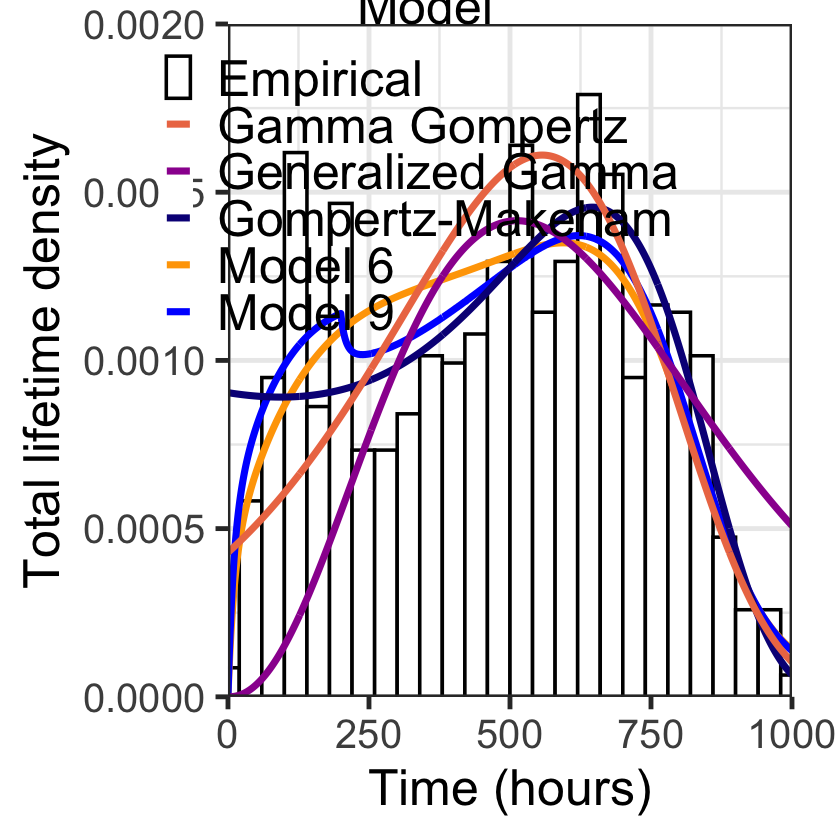

In [66]:
#Figure 7 A
#Comparison of experimental total lifetime distribution with parametric distributions for models 6, 9 and one phase models

#Parametric distributions
dis9 =  sapply(0:1000,function(t)(df_td_2dep_cont(t,gam_sup,m_sup,lim,kD1e_9, kD2e_9,d_9,f,g,h))) #lifetime distribution model 9
dis6 = sapply(0:1000,function(t)(df_td_dep_cont(t,gam,m,kD1e_6, kD2e_6,d_6,f,g,h)))#lifetime distribution model 6
disgm = sapply(0:1000,function(c)(dis_makeham(c,j,n,l)))#lifetime distribution Gompertz-Makeham one phase
dis_gamg = sapply(0:1000,function(c)( alpha*s*exp(alpha*c)*beta^s/(beta-1+exp(c*alpha))^(s +1)))#lifetime distribution Gamma-Gompertz one phase
dis_gg = dgengamma.orig(0:1000,p,r,q)#lifetime distribution Generalized Gamma one phase

#dataframes for plot
data_th = data.frame(Time = 0:1000,gm = disgm, gamg = dis_gamg,gg = dis_gg, dis6, dis9) 
data_hist = data.frame(TD)
                                 
#Plot
ggplot()+ geom_histogram(data = data_hist,aes(x = TD,y = ..density..,colour = 'Empirical'), binwidth = 40, fill = 'white',linewidth = 1)+
geom_line(data = data_th, aes(x = Time, y = dis6, colour = 'haz'),linewidth = 2)+
geom_line(data = data_th, aes(x = Time,y = dis9, colour = 'haz9'),linewidth = 2)+
geom_line(data = data_th, aes(x = Time, y = gm,colour = 'gm'),linewidth = 2) +     
geom_line(data = data_th, aes(x = Time, y = gamg,colour = 'gamg'),linewidth = 2)+
geom_line(data = data_th, aes(x = Time, y = gg, colour = 'gg'),linewidth = 2) +                        

theme_bw(base_size = 30)  +                                                 
labs(y ='Total lifetime density',x='Time (hours)')+
  scale_color_manual(
    name = "Model",  # legend title
    values = c('black',rev(viridis::plasma(4))[2:4],'orange','blue','red'),
    labels = c("ker" = "Kernel estimator",
      "haz9" = 'Model 9',
      "haz" = 'Model 6',
      "gm" = 'Gompertz-Makeham',
      "gg" = 'Generalized Gamma',
     "gamg" = 'Gamma Gompertz'
    )
  ) +   # discrete Viridis colors for each curve
  guides(
    colour = guide_legend(
      override.aes = list(size = 2),  # change line thickness in legend
      title.position = "top",
      title.hjust = 0.5
    )
  )+theme + theme(legend.position = c(0.35, 0.8),plot.margin = unit(c(1, 2, 1, 1), "lines"))+scale_x_continuous(expand = c(0, 0)) + 
  scale_y_continuous(expand = c(0, 0))+coord_cartesian( ylim = c(0, 0.002),xlim=c(0,1000))
ggsave(file = "./Figures/Figure7A.png",  width = 15, height = 10) 

### Figure 7 B

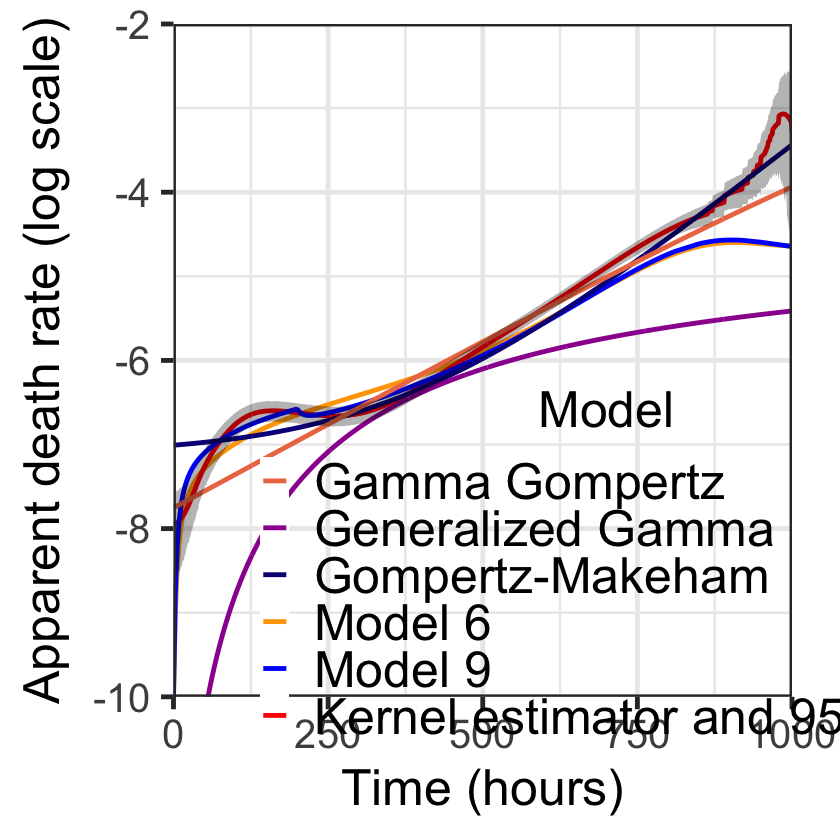

In [67]:
#Figure 7 B

#Comparison of experimental non-parametric apparent death rate with parametric apparent death rates for models 6, 9 and one phase models

#Parametric hazard rates
Haz_th_9 = sapply(c((0:200)*3,(60:81)*10,(85:92)*10,950,1000), function(c)(haz_death9(c,gam_sup,m_sup,lim,kD1e_9,kD2e_9,d_9,f,g,h))) #model 9
Haz_th_6 = sapply(c((0:200)*3,(60:100)*10) , function(c)(haz_death6(c,gam,m,kD1e_6, kD2e_6,d_6,f,g,h))) #model 6
haz_gm = log(sapply(0:1000,function(c)(j+n*exp(l*c)))) #Gompertz-Makeham
haz_gamg = log(sapply(0:1000,function(c)(alpha*s*exp(alpha*c)/(beta-1+exp(alpha*c))))) #Gamma Gompertz
haz_gg = log(hgengamma.orig(0:1000,p,r,q))#Generalized Gamma

#dataframes for plot
data_th = data.frame(Time = 0:1000,ker = log(Kopt),gm = haz_gm,  gamg = haz_gamg,gg = haz_gg)
data_6 = data.frame(Time = c((0:200)*3,(60:100)*10), haz6 = log(Haz_th_6))
data_9 = data.frame(Time = c((0:200)*3,(60:81)*10,(85:92)*10,950,1000), haz9 = log(Haz_th_9))
data = data.frame(Time = Grid_exp, Hazard = Kopt,inf = CI_infdt, sup = CI_supdt)

#Plot                                
ggplot() +geom_line(data = data_6, aes(x = Time, y = haz6, colour = 'haz'))+
geom_line(data = data_th, aes(x = Time, y = ker, colour = 'ker')) +
geom_line(data = data_9, aes(x = Time,y = haz9, colour = 'haz9'))+
geom_line(data = data_th, aes(x = Time, y = gm,colour = 'gm')) +     
geom_line(data = data_th, aes(x = Time, y = gamg,colour = 'gamg'))+
geom_line(data = data_th, aes(x = Time, y = gg, colour = 'gg')) +                        
geom_ribbon( data = data,aes(x=Time,ymin = inf, ymax = sup),fill = 'black',alpha=0.3,colour=NA)+
theme_bw(base_size = 20)+                                                       
labs(y ='Apparent death rate (log scale)',x='Time (hours)')+
  scale_color_manual(
    name = "Model",  # legend title
    values = c(rev(viridis::plasma(4))[2:4],'orange','blue','red'),
    labels = c( "haz9" = 'Model 9',"haz" = 'Model 6', "gm" = 'Gompertz-Makeham', "gg" = 'Generalized Gamma',"ker" = "Kernel estimator and 95% CI",
      "gamg" = 'Gamma Gompertz' )) +   # discrete Viridis colors for each curve
  guides(
    colour = guide_legend(
      override.aes = list(size = 2),  # change line thickness in legend
      title.position = "top",
      title.hjust = 0.5
    )
  )+theme + theme(legend.position = c(0.7, 0.2),plot.margin = unit(c(1, 2, 1, 1), "lines"))+scale_x_continuous(expand = c(0, 0)) + 
  scale_y_continuous(expand = c(0, 0))+coord_cartesian( ylim = c(-10, -2),xlim=c(0,1000))
ggsave(file = "./Figures/Figure7B.png",  width = 15, height = 10) 

## Application to mice survival 

### Parameter values (Table S6)

In [100]:
#load mice data
mice1 = read.csv('./Data/C57males.csv') #experimental data 1 (C57BL6/J male)
mice2 = read.csv('./Data/C57femelles.csv') #experimental data 2 (C57BL6/J female)
mice3 = read.csv('./Data/AKRJ.csv') #experimental data 3 (AKR/J)

#Defining some parameters
bw = 15 #bandwidth for non-parametric kernel estimation of Smurf transition rate in mice
bw_d = 10 #bandwidth for non-parametric kernel estimation of death rate once Smurf in mice
n_var = 30000 #number of repetitions for Monte-Carlo variance computation

T = 0:1100 #array of times for Smurf transition rate
T_var = (0:125)*4 #array of times for variance computation
T_d = 0:500 #array of times for death rate once Smurf
comp = array(0.0001,dim = length(T_var))

In [103]:
#Data treatment 
#Uniformly distributing time spent Smurf in the last interval for those who were never scored Smurf
res1= mice_treatment_add_smurf(mice1)
res2= mice_treatment_add_smurf(mice2)
res3 = mice_treatment_add_smurf(mice3)
Sm = res1$S #time spent Smurf pop 1
Non_Sm = res1$NS #time spent non-Smurf pop 1
Sm2 = res2$S #time spent Smurf pop 2
Non_Sm2 = res2$NS#time spent non-Smurf pop 2
Sm3 = res3$S #time spent Smurf pop 3
Non_Sm3= res3$NS #time spent non-Smurf pop 3
NonS = c(Non_Sm, Non_Sm2) #time spent non-Smurf pop 1+2
SM = c(Sm, Sm2) #time spent Smurf pop 1+2

N12= length(SM) #data size pop 1+2
N3 = length(Sm3)#data size pop 3

In [28]:
#Populations 1 and 2 (C57), maximum likelihood parameters 
#Smurf transition rate, Gompertz-Makeham fm+gm*exp(hm*t)
A = 0.005+ (0.1-0.01)*(1:1000)/10000
der_lik1 = sapply(A,function(d)(param_Gomp_Mak2(NonS-min(NonS),d)[1])) 
ind_h = which(der_lik1[!is.na(der_lik1)]== max(der_lik1[!is.na(der_lik1)])) 
hm = A[ind_h]  
gomp = param_Gomp_Mak2(NonS-min(NonS),hm)
fm = gomp[2]
gm1 = gomp[3]

#Death rate once Smurf kD1m + kD2m*exp(-dm*t)
A = 0.01+ (0.1-0.01)*(1:1000)/10000
gomp_D = g_m_death(SM, A, 1/3500, 100/3500)
kD1m = gomp_D[1] 
kD2m = gomp_D[2]
dm = gomp_D[5]   

In [29]:
#Population 3 (AKR/J) maximum likelihood parameters

#Smurf transition rate, Gompertz-Makeham f3+g3*exp(h3*t)
A = 0.005+ (0.1-0.01)*(1:1000)/10000
der_lik1 = sapply(A,function(d)(param_Gomp_Mak2(Non_Sm3-min(Non_Sm3),d)[1])) 
ind_h = which(der_lik1[!is.na(der_lik1)]== max(der_lik1[!is.na(der_lik1)])) #finding d_gi for which likelihood is maximum
h3 = A[ind_h]  
gomp = param_Gomp_Mak2(Non_Sm3-min(Non_Sm3),h3)
f3 = gomp[2]
g3 = gomp[3]
                  
#Death rate once Smurf kD13 + kD23*exp(-d3*t)
A = 0.00+ (0.1-0.01)*(1:1000)/10000 
gomp_D3 = g_m_death(Sm3, A, 0/3500, 800/3500)
kD13 = gomp_D3[1] 
kD23 = gomp_D3[2]
d3 = gomp_D3[5]

In [30]:
#Parameter values
print('Populations 1 and 2 (C57BL6/J)')
print(paste('Gompertz-Makeham Smurf transition rate: f=',fm, 'g=', gm1, 'h=', hm))
print(paste('Decreasing exponential death rate: k1=',kD1m, 'k2=', kD2m, 'd=', dm))
print('Population 3 (AKR/J)')
print(paste('Gompertz-Makeham Smurf transition rate: f=',f3, 'g=', g3, 'h=', h3))
print(paste('Decreasing exponential death rate: k1=',kD13, 'k2=', kD23, 'd=', d3))


[1] "Populations 1 and 2 (C57)"
[1] "Gompertz-Makeham Smurf transition rate: f= -0.00166708705012947 g= 0.00196341687633859 h= 0.006557"
[1] "Decreasing exponential death rate: k1= 0.00366493490407149 k2= 0.0878300329144964 d= 0.019"
[1] "Population 3 (AKRJ)"
[1] "Gompertz-Makeham Smurf transition rate: f= -0.00125667059623698 g= 0.00160949962655904 h= 0.009752"
[1] "Decreasing exponential death rate: k1= 0.0634782392876632 k2= -4.59643351911481e-11 d= 0.009"


In [31]:
#Survival function empirical error bands
CI_surv_3 = NS_CI('gm','np',c(f3,g3,h3), simu_death,sort(Non_Sm3),init_size = N3, nrep = 500)
CI_surv_1 = NS_CI('gm','np',c(fm,gm1,hm), simu_death,sort(Non_S),init_size = N12,nrep = 500)
CI_surv_s3 = S_CI('gm',3,c(f3,g3,h3),c(kD13,kD23,d3),sort(Sm3),init_size = N3,nrep = 500)
CI_surv_s1 = S_CI('gm',3,c(fm,gm1,hm),c(kD1m,kD2m,dm),sort(SM),init_size = N12, nrep = 500)

### Figure 8 A

In [ ]:
#Figure 8 A 
#Populations 1 and 2 (C57)

est_m = sapply(T_d, function(t)(ker_est_gamma_c(t,sort(NonS-min(NonS)),bw)))#estimator of Smurf transition rate
ker_mice =function(t)(ker_est_gamma_c(t,sort(NonS-min(NonS)),bw)) #auxiliary function to compute variance
Var_M1=sapply(T_var, function(t)(Var_M_C(t,length(NonS),gamma_ker,ker_mice,n_var,bw,5000))) #variance for confidence interval
    
#cutoff of lower confidence interval to make sure it is non 0 to take the log
inf_ci = est_m[T_var + 4]-q95*sqrt(Var_M1)
inf_ci[inf_ci <= 0.000001] = 0.000001

#dataframes for plot
data = data.frame( times = sort(NonS)-min(NonS) ,surv = length(NonS):1)
data_v = data.frame(sup = log(est_m[T_var + 4]+q95*sqrt(Var_M1)),inf = log(inf_ci), t = T_var)
data_s = data.frame(surv = length(SM)*exp(-fm*T -gm1/hm*exp(hm*T) + gm1/hm), T)
data_h = data.frame(t= T_d, est=log(est_m), param = log(fm + gm1*exp(hm*T_d)))
data_CI1 = data.frame(inf1ns =CI_surv_1[1,], sup1ns = CI_surv_1[2,], time = (1:(length(CI_surv_1[1,])))*10) 
data_CI_s1 = data.frame(inf1s =CI_surv_s1[1,], sup1s = CI_surv_s1[2,],time = (N12:1))

#Plots
g_s1 <- ggplot()+ 
geom_line(data = data_s, aes(x=T, y =surv,colour = 'Modelled non-Smurf\nsurvival and 95%\n error band'),lwd = 1)+
geom_ribbon(data=data_CI1, aes(x=time,ymin = inf1ns, ymax = sup1ns,colour='Estimated 95% error band') ,fill='grey',alpha=0.4,color = mycol)+
#scale_y_continuous(expand = c(0, 0),
    # Features of the first axis   name = "Non-Smurf population")+
geom_point(data = data, aes(times,surv, colour='Empirical survival'),alpha = 1,shape=3,size = 1)+theme+
scale_color_manual(name = "", values = c('Modelled non-Smurf\nsurvival and 95%\n error band' = 'grey', 'Empirical survival' = 'black'
                                        ))+labs(y ='Non-Smurf survival',x='Time (days)')+theme(legend.position = c(0.4, 0.2))+
coord_cartesian(xlim = c(0,500))+scale_x_continuous(expand = c(0, 0))+theme(legend.position = c(0.4, 0.3),legend.key.height = unit(2, "cm"))


g_h1 <-  ggplot()+ 
geom_line(data = data_h, aes(x=t, y =est,colour = 'Non-parametric\nestimation and 95% CI'),lwd = 1)+
#scale_y_continuous(expand = c(0, 0),
    # Features of the first axis
    #name = "Smurf transition rate (log scale)")+
theme+
geom_line(data = data_h, aes(x = t, y = param, colour = 'Parametric estimation'),lwd = 1)+ 
geom_ribbon(data=data_v, aes(x=t,ymin = inf, ymax = sup,colour='Estimated 95% error band'),fill='red',alpha=0.4,colour = NA)+
scale_color_manual(name = "", values = c('Non-parametric\nestimation and 95% CI' = 'red', 'Estimated 95% error band' = 'red','Parametric estimation' = 'blue'
                                        ))+labs(y ='Smurf transition rate (log scale)',x='Time (days)')+
coord_cartesian(xlim = c(0,500), ylim = c(-2,-12))+scale_x_continuous(expand = c(0, 0))+theme(legend.position = c(0.56, 0.3),legend.key.height = unit(2, "cm"))



est_md = sapply(T_d, function(t)(ker_est_gamma_c(t,sort(SM-min(SM)),bw_d))) #estimator of death rate once Smurf 
ker_mice_d = function(t)(ker_est_gamma_c(t,sort(SM-min(SM)),bw_d)) #auxiliary function to compute variance
Var_M1_d=sapply(T_var, function(t)(Var_M_C(t,length(SM),gamma_ker,ker_mice_d,n_var,bw_d,5000)))#Variance for confidence interval
#cutoff of lower confidence interval to make sure it is non 0 to take the log
inf_cid = est_md[T_var + 4]-q95*sqrt(Var_M1_d)
inf_cid[inf_cid <= 0.000001] = 0.000001

#dataframes for plots
data = data.frame( times = sort(SM)-min(SM) ,surv = length(SM):1)
data_v = data.frame(sup = log(est_md[T_var + 4]+q95*sqrt(Var_M1_d)),inf = log(inf_cid), t = T_var)
data_s = data.frame(surv = length(SM)*exp(-kD1m*T +kD2m/dm*exp(-dm*T) - kD2m/dm), T)
data_h = data.frame(t = T_d, est = log(est_md), param = log(kD1m + kD2m*exp(-dm*T_d)))

#Plots
g_s1d <- ggplot()+ 
geom_line(data = data_s, aes(x=T, y =surv,colour = 'Modelled Smurf\nsurvival and 95%\n error band'),lwd = 1)+
scale_y_continuous(expand = c(0, 0),
    # Features of the first axis
    name = "Smurf survival")+
scale_x_continuous(expand = c(0, 0))+
geom_ribbon(data=data_CI_s1, 
            aes(y=time,xmax = sup1s, xmin = inf1s) ,fill='grey',alpha=0.4,color = mycol)+
geom_point(data = data, aes(times,surv, colour='Empirical survival'),alpha = 1,shape=3,size = 1)+theme+
scale_color_manual(name = "", values = c('Modelled Smurf\nsurvival and 95%\n error band' = 'grey', 'Empirical survival' = 'black'
                                      ))+labs(y ='Smurf survival',x='Time spent Smurf (days)')+
coord_cartesian(xlim = c(0,200))+theme(legend.position = c(0.6, 0.8),legend.key.height = unit(2, "cm"))

g_h1d <-  ggplot()+ 
geom_line(data = data_h, aes(x=t, y =est,colour = 'Non-parametric\nestimation and 95% CI'),lwd = 1)+
#scale_y_continuous(expand = c(0, 0))+
theme+theme(legend.key.height = unit(2, "cm"),legend.position = c(0.5, 0.3))+
geom_line(data = data_h, aes(x = t, y = param, colour = 'Parametric estimation'),lwd = 1)+ 
 geom_ribbon(data=data_v, aes(x=t,ymin = inf, ymax = sup,colour='Estimated 95% error band'),fill='red',alpha=0.4,colour = colo)+
scale_color_manual(name = "", values = c('Non-parametric\nestimation and 95% CI' = 'red', 'Estimated 95% error band' = 'red','Parametric estimation' = 'blue'
                                        ))+labs(y ='Death rate once Smurf (log scale)',x='Time spent Smurf (days)')+
coord_cartesian(xlim = c(0,200), ylim = c(-2,-12))+scale_x_continuous(expand = c(0, 0))


### Figure 8 B

In [34]:
#Figure 8 B
#Population 3 (AKR/J)
est_m3 = sapply(T_d, function(t)(ker_est_gamma_c(t,sort(Non_Sm3-min(Non_Sm3)),bw)))  #estimator of Smurf transition rate 
ker_mice3 =function(t)(ker_est_gamma_c(t,sort(Non_Sm3-min(Non_Sm3)),bw))  #auxiliary function to compute variance
Var_M3=sapply(T_var, function(t)(Var_M_C(t,length(Non_Sm3),gamma_ker,ker_mice3,n_var,bw,5000))) #Variance for confidence interval
#cutoff of lower confidence interval to make sure it is non 0 to take the log
inf_ci3 = est_m3[T_var + 4]-q95*sqrt(Var_M3)
inf_ci3[inf_ci3 <= 0.000001] = 0.000001

#dataframes for plots
data = data.frame( times = sort(Non_Sm3)-min(Non_Sm3) ,surv = length(Non_Sm3):1)
data_v = data.frame(sup = log(est_m3[T_var + 4]+q95*sqrt(Var_M3)),inf = log(inf_ci3), t = T_var)
data_s = data.frame(surv = length(Sm3)*exp(-f3*T -g3/h3*exp(h3*T) + g3/h3), T)
data_h = data.frame(t = T_d, est=log(est_m3), param = log(f3 + g3*exp(h3*T_d)))
data_CI_s3 = data.frame( inf3s =CI_surv_s3[1,], sup3s = CI_surv_s3[2,], time = (N3:1))
data_CI3 = data.frame(inf3ns =CI_surv_3[1,], sup3ns = CI_surv_3[2,],time = (1:(length(CI_surv_3[1,])))*10) 
#Plots
                
g_s3 <- ggplot()+ 
geom_line(data = data_s, aes(x=T, y =surv,colour = 'Modelled non-Smurf\nsurvival and 95%\n error band'),lwd = 1)+
geom_ribbon(data=data_CI3, aes(x=time,ymin = inf3ns, ymax = sup3ns,colour='Estimated 95% error band'), fill='grey',alpha=0.4,color = mycol)+
scale_y_continuous(expand = c(0, 0),
    # Features of the first axis
    name = "Non-Smurf population")+ theme+
coord_cartesian(xlim = c(0,400),ylim = c(0,N3))+scale_x_continuous(expand = c(0, 0))+ 
theme( legend.key.height = unit(2, "cm"),legend.position = c(0.4, 0.3))+
geom_point(data = data, aes(times,surv, colour='Empirical survival'),alpha = 1,shape=3,size = 1)+
scale_color_manual(name = "", values = c('Modelled non-Smurf\nsurvival and 95%\n error band' = 'grey', 'Estimated 95% error band' = 'red', 'Empirical survival' = 'black'
                                        ))+labs(y ='Non-Smurf survival',x='Time (days)')

g_h3 <-  ggplot()+ 
geom_line(data = data_h, aes(x=t, y =est,colour = 'Non-parametric\nestimation and 95% CI'),lwd = 1)+
scale_y_continuous(expand = c(0, 0))+
theme+ theme(  legend.key.height = unit(2, "cm"))+
  geom_line(data = data_h, aes(x = t, y = param, colour = 'Parametric estimation'),lwd = 1)+ 
 geom_ribbon(data=data_v, aes(x=t,ymin = inf, ymax = sup,colour='Estimated 95% error band'),fill='red',alpha=0.4,colour = NA)+
scale_color_manual(name = "", values = c('Non-parametric\nestimation and 95% CI' = 'red', 'Estimated 95% error band' = 'red','Parametric estimation' = 'blue'
                                        ))+labs(y ='Smurf transition rate (log scale)',x='Time (days)')+
 coord_cartesian(xlim = c(0,400),ylim = c(-2,-12))+scale_x_continuous(expand = c(0, 0))+theme(legend.position = c(0.57, 0.3))


est3d = sapply(T_d, function(t)(ker_est_gamma_c(t,sort(Sm3-min(Sm3)),bw_d)))#estimator of death rate once Smurf
ker_mice_3d = function(t)(ker_est_gamma_c(t,sort(Sm3-min(Sm3)),bw_d)) #auxiliary function to compute variance
Var_M3_d=sapply(T_var, function(t)(Var_M_C(t,length(Sm3),gamma_ker,ker_mice_3d,n_var,bw_d,5000)))#Variance for confidence interval
#cutoff of lower confidence interval to make sure it is non 0 to take the log
inf_ci3d = est3d[T_var + 4]-q95*sqrt(Var_M3_d)
inf_ci3d[inf_ci3d <= 0.000001] = 0.000001

#dataframes for plots
data = data.frame( times = sort(Sm3)-min(Sm3) ,surv = length(Sm3):1)
data_v = data.frame(sup = log(est3d[T_var + 4]+q95*sqrt(Var_M3_d)),inf = log(inf_ci3d), t = T_var )
data_s = data.frame(surv = length(Sm3)*exp(-kD13*T +kD23/d3*exp(-d3*T) - kD23/d3), T)
data_h = data.frame( t= T_d, est = log(est3d), param = log(kD13 + kD23*exp(-d3*T_d)))

#Plots
g_s3d <- ggplot()+ 
geom_line(data = data_s, aes(x=T, y =surv,colour = 'Modelled Smurf\nsurvival and 95%\nerror band'),lwd = 1)+
scale_y_continuous(expand = c(0, 0))+
geom_ribbon(data=data_CI_s3, 
            aes(y=time,xmax = sup3s, xmin = inf3s)  ,fill='grey',alpha=0.4,color = mycol)+geom_point(data = data, aes(times,surv, colour='Empirical survival'),alpha = 1,shape=3,size = 1)+theme+
scale_color_manual(name = "", values = c('Modelled Smurf\nsurvival and 95%\nerror band' = 'grey', 'Empirical survival' = 'black'
                                        ))+labs(y ='Smurf survival',x='Time spent Smurf (days)')+
                coord_cartesian(xlim = c(0,70))+scale_x_continuous(expand = c(0, 0))+
               theme( legend.position = c(0.5, 0.85), legend.key.height = unit(2, "cm"))


g_h3d <-  ggplot()+ 
geom_line(data = data_h, aes(x=t, y =est,colour = 'Non-parametric\nestimation and 95% CI'),lwd = 1)+
theme+
  geom_line(data = data_h, aes(x = t, y = param, colour = 'Parametric estimation'),lwd = 1)+ 
 geom_ribbon(data=data_v, aes(x=t,ymin = inf, ymax = sup,colour='Estimated 95% error band'),fill='red',alpha=0.4,colour = NA)+
scale_color_manual(name = "", values = c('Non-parametric\nestimation and 95% CI' = 'red', 'Estimated 95% error band' = 'red','Parametric estimation' = 'blue'
                                        ))+labs(y ='Death rate once Smurf (log scale)',x='Time spent Smurf (days)')+
 coord_cartesian(xlim = c(0,70),ylim = c(-2,-12))+scale_x_continuous(expand = c(0, 0))+ theme(legend.position = c(0.5, 0.3))+
theme(  legend.key.height = unit(2, "cm"))

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_ribbon()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_ribbon()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_ribbon()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_ribbon()`).”


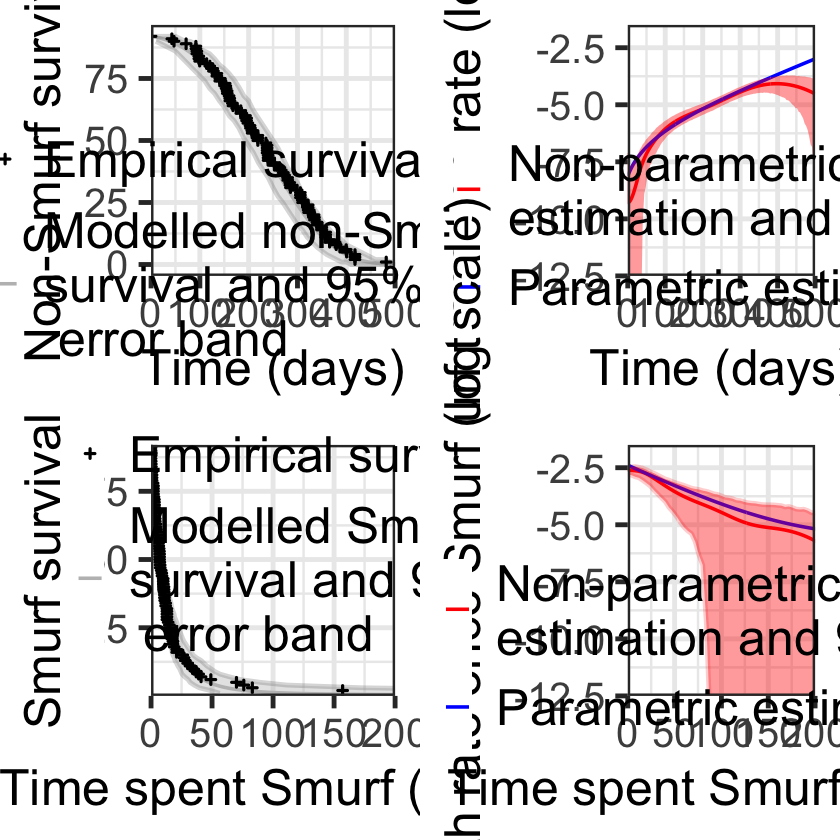

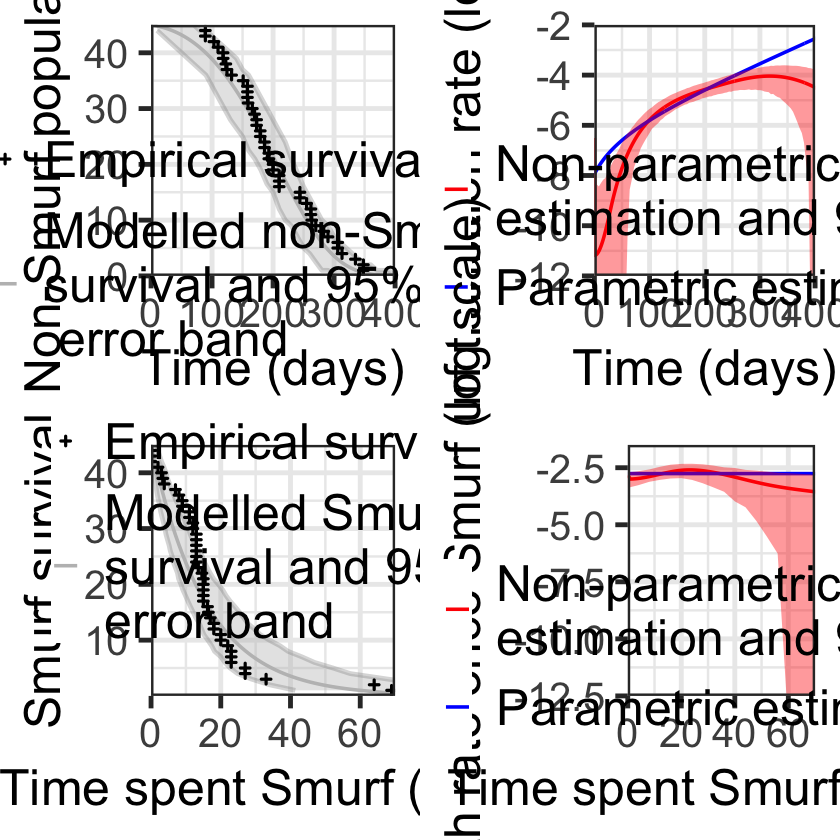

In [68]:
#Plots

#Figure 8 A
#Populations 1 and 2, Smurf and non-Smurf survival, Smurf transition rate and death rate once Smurf
gm12 <-grid.arrange(g_s1, g_h1, g_s1d, g_h1d, nrow = 2)
gm12 <- as_ggplot(gm12)
ggsave(file = "./Figures/Figure8A.png",width = 15, height = 15)

#Figure 8 B
#Population 3, Smurf and non-Smurf survival, Smurf transition rate and death rate once Smurf
gm3 <-grid.arrange(g_s3, g_h3, g_s3d, g_h3d, nrow = 2)
gm3 <- as_ggplot(gm3)
ggsave(file = "./Figures/Figure8B.png",width = 15, height = 15)

# Supplementary Tables and Figures

### Figure S1

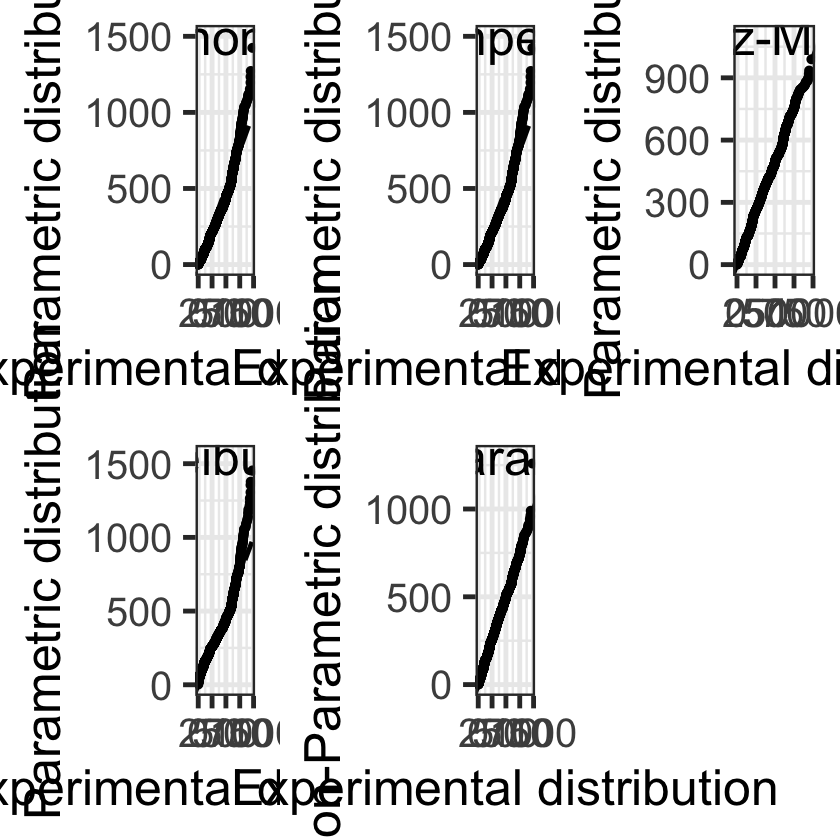

In [69]:
#Figure S1

##QQ-plots to compare the experimental distribution of time spent non-Smurf to theoretical distributions

quant = (1:length(TNS))/length(TNS) #experimental quantiles 

#computing theoretical quantiles
Tp = plot_qq_pop('p','np',c(a,b),gam_adapt_d,'s',12000)
Tp = quantile(Tp, quant) #quantiles of polynomial hazard rate
Tg = plot_qq_pop('g','np',c(c,d),gam_adapt_d,'s',12000)
Tg = quantile(Tg, quant) #quantiles of gompertz hazard rate
Tgm = plot_qq_pop('gm','np',c(f,g,h),gam_adapt_d,'s',12000)
Tgm = quantile(Tgm, quant) #quantiles of gompertz-makeham hazard rate
Tw = plot_qq_pop('w','np',c(v,w),gam_adapt_d,'s',12000)
Tw = quantile(Tw, quant) #quantiles of weibull hazard rate
Tnp = plot_qq_pop('np','np',gam_adapt_s,gam_adapt_d,'s',12000)
Tnp = quantile(Tnp, quant) #quantiles of non-parametric kernel hazard rate
data = data.frame(Tp,Tg,Tgm,Tw,Tnp,TNS)

#Plots 
P <- ggplot() + 
  geom_abline(aes(slope = 1, intercept = 0), linetype = 2)+
theme+  labs(x = 'Experimental distribution', y = 'Parametric distribution')

P_p <- P + geom_point(aes(x = sort(TNS), y = sort(Tp)), size = 1) +annotate("text", x=200, y=1500, label= 'Polynomial') 

P_g <- P +  geom_point(aes(x = sort(TNS), y = sort(Tp)),size = 1) +annotate("text", x=190, y=1500, label= 'Gompertz') 

P_gm <- P +  geom_point(aes(x = sort(TNS), y = sort(Tgm)),size = 1) +annotate("text", x=350, y=1100, label= 'Gompertz-Makeham') 

P_w <- P +  geom_point(aes(x = sort(TNS), y = sort(Tw)),size = 1) +annotate("text", x=180, y=1550, label= 'Weibull') 

P_np <-P + geom_point(aes(x = sort(TNS), y = sort(Tnp)),size = 1) +labs(y = 'Non-Parametric distribution')+annotate("text", x=320, y=1300, label= 'Non-parametric') 

gt<-grid.arrange(P_p,P_g,P_gm,P_w, P_np, nrow = 2)
gt <- as_ggplot(gt)
ggsave(file = "./Figures/FigureS1.pdf",  width = 21, height = 14) 


### Table S1

In [41]:
#Values for Table S1
#Comparison of models for Smurf hazard rate with BIC and Wasserstein distance 

#printing BIC
print(paste('BIC Gompertz-Makeham',BIC(TNS,TNS,function(t,y)(haz_smurf_gm(t,y,f,g,h)),3)))
print(paste('BIC Gompertz',BIC(TNS,TNS,function(t,y)(haz_smurf_g(t,y,c,d)),2)))
print(paste('BIC Polynomial',BIC(TNS,TNS,function(t,y)(haz_smurf_p(t,y,a,b)),2)))
print(paste('BIC Weibull',BIC(TNS,TNS,function(t,y)(haz_smurf_w(t,y,v,w)),2)))

#computing 1D Wasserstein distances                          
was_gm = emp_wasserstein1D('gm',TNS,c(f,g,h))
was_g = emp_wasserstein1D('g',TNS,c(c,d))
was_p = emp_wasserstein1D('p',TNS,c(a,b))
was_w = emp_wasserstein1D('w',TNS,c(v,w))

#printing 1D Wasserstein distances                          
print(paste('Gompertz-Makeham Wasserstein distance',was_gm[1], 'Standard deviation',was_gm[2]))
print(paste('Gompertz Wasserstein distance',was_g[1], 'Standard deviation',was_g[2]))
print(paste('Weibull Wasserstein distance',was_w[1], 'Standard deviation',was_w[2]))
print(paste('Polynomial Wasserstein distance',was_p[1], 'Standard deviation',was_p[2]))

[1] "BIC Gompertz-Makeham 15683.7910752402"
[1] "BIC Gompertz 15729.1212831832"
[1] "BIC Polynomial 15818.8016331047"
[1] "BIC Weibull 15917.2706705292"
[1] "Gompertz-Makeham Wasserstein distance 10.0245133558842 Standard deviation 2.3829330578069"
[1] "Gompertz Wasserstein distance 22.740124809117 Standard deviation 2.88337101085611"
[1] "Weibull Wasserstein distance 43.3472316944001 Standard deviation 3.42834817659877"
[1] "Polynomial Wasserstein distance 46.3264718347973 Standard deviation 5.70851034701456"


### Figure S2

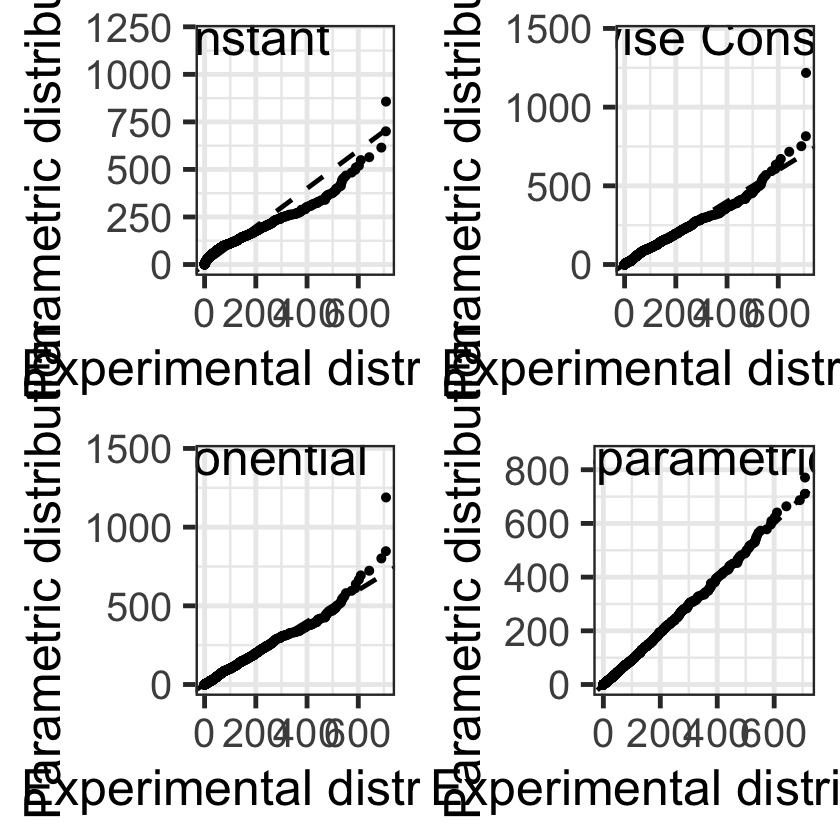

In [70]:
#Figure S2
##QQ-plots to compare the experimental distribution of time spent Smurf to theoretical distributions

quant = (1:length(TS))/length(TS) #experimental quantiles 

#computing theoretical quantiles
Tc = plot_qq_pop('gm',1,c(f,g,h), c(kDi),'d',12000,n=200)
Tc = quantile(Tc, quant,na.rm = TRUE) #quantiles for constant hazard rate
Tpc = plot_qq_pop('gm',2,c(f,g,h), c(kD1i, kD2i),'d',12000,n=200)
Tpc = quantile(Tpc, quant,na.rm = TRUE) #quantiles for two constants hazard rate
Te = plot_qq_pop('gm',3,c(f,g,h), c(kD1ei, kD2ei,d_ei),'d',12000,n=200)
Te = quantile(Te, quant,na.rm = TRUE) #quantiles for decreasing exponential hazard rate
Tnps = plot_qq_pop('gm','np',c(f,g,h), gam_adapt_d,'d',12000,n=200)
Tnps = quantile(Tnps, quant,na.rm = TRUE) #quantiles for non-parametric kernel hazard rate

#Plots
P_c <- P +  geom_point(aes(x = sort(TS), y = sort(Tc)), size = 1) +annotate("text", x=100, y=1200, label= 'Constant') 

P_pc <- P +  geom_point(aes(x = sort(TS), y = sort(Tpc)), size = 1) +annotate("text", x=220, y=1450, label= 'Piecewise Constant') 

P_e <- P +  geom_point(aes(x = sort(TS), y = sort(Te)), size = 1) +annotate("text", x=130, y=1450, label= 'Exponential') 

P_nps <-P + geom_point(aes(x = sort(TS), y = sort(Tnps)), size = 1) +annotate("text", x=200, y=850, label= 'Non-parametric') 

gt<-grid.arrange(P_c,P_pc,P_e,P_nps, nrow = 2)
gt <- as_ggplot(gt)
ggsave(file = "./Figures/FigureS2.pdf",width = 15, height = 15)

### Figure S3

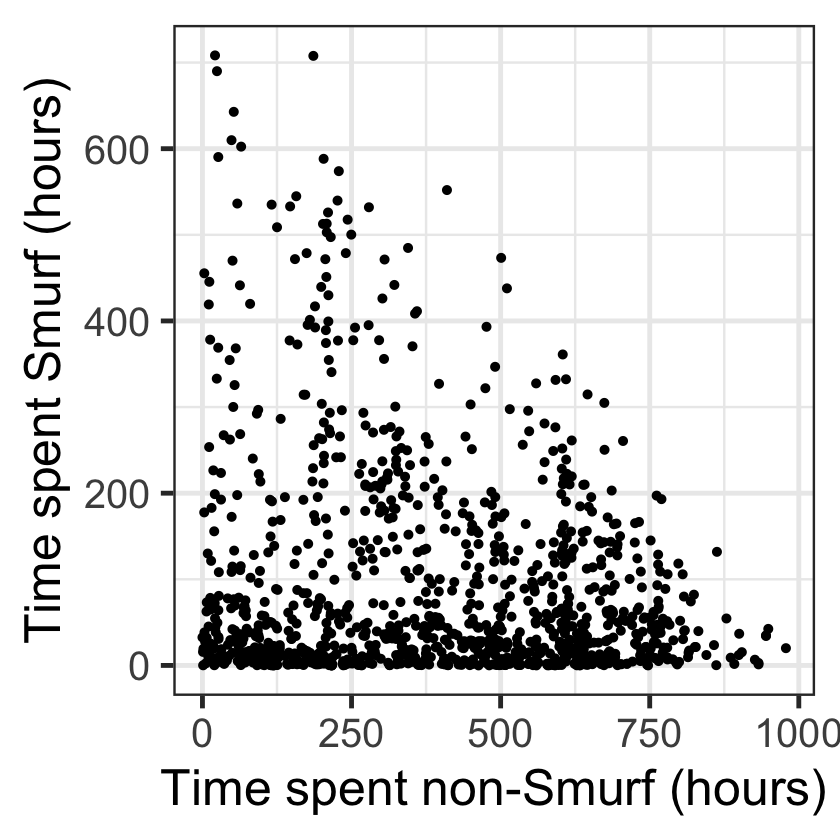

In [71]:
#Figure S3
#XY plot of time spent Smurf vs time spent non-Smurf
ggplot() + geom_point(aes(x= TNS, y = TS), size = 1)+theme+
labs(x='Time spent non-Smurf (hours)', y = 'Time spent Smurf (hours)')
ggsave(file = "./Figures/FigureS3.pdf",  width = 10, height = 10) 

### Figure S4

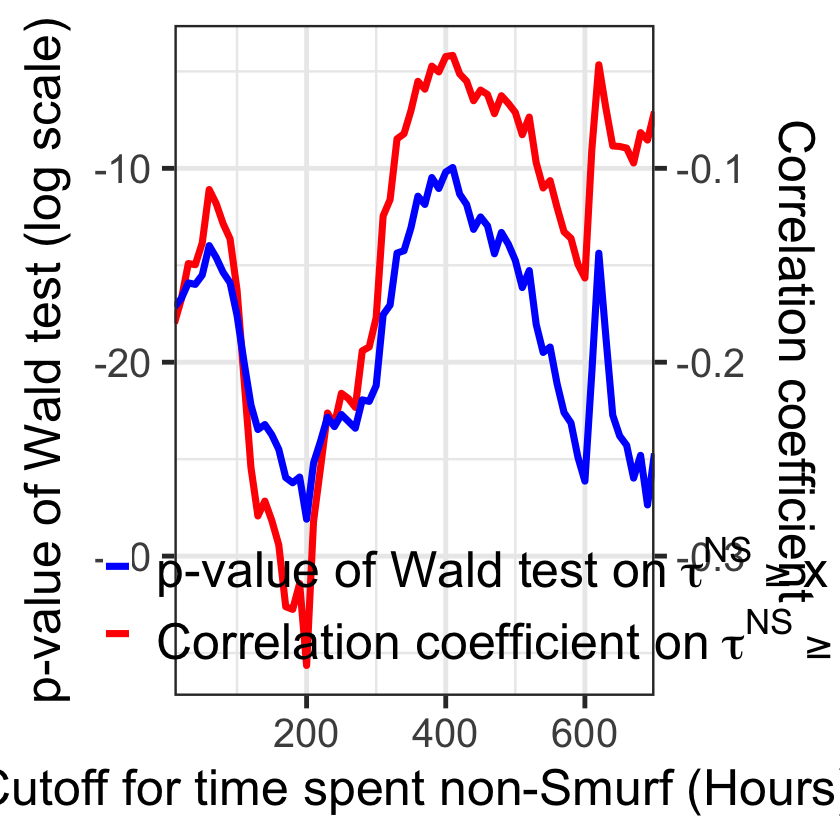

In [72]:
#Figure S4
#Correlation coefficient and p-value of Wald test of independence depending on subset of time spent non-Smurf

tab = (1:70)*10 #array to compute correlation and Wald test p-value 
score_sup = sapply(tab, function(l)(score_dep_sup(l,TNS,TS))) #Wald test of independence
corr_sup = sapply(tab,function(l)(cor_lim_sup(l,TNS,TS))) #correlation coefficient
data = data.frame(tab, score_sup, corr_sup) #dataframe for plot

#Plot
ggplot() +
scale_y_continuous(
    # Features of the first axis
    # Add a second axis and specify its features
    sec.axis = sec_axis(~./100, name="Correlation coefficient")
  ) +theme + scale_x_continuous(expand = c(0,0)) +               
 geom_line(data = data, aes(x=tab, y = score_sup,colour = 'score_sup'),lwd = 2)+
 geom_line(data = data, aes(x=tab, y = 100*corr_sup, colour = 'corr_sup'),lwd = 2)  +  
scale_color_manual(
    name = "",  # legend title
    values = c('blue', 'red'),
    labels = unname(TeX(c("score_sup" = 'p-value of Wald test on $\\tau^{NS} \\geq x$',
               "corr_sup" = 'Correlation coefficient on $\\tau^{NS} \\geq x$')))
    )+
labs(y = 'p-value of Wald test (log scale)',x='Cutoff for time spent non-Smurf (Hours)')+
                  theme(legend.position = c(0.65, 0.2))
                  
ggsave(file = "./Figures/FigureS4.pdf",  width = 15, height = 10) 

### Figure S5

Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”
Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”
Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”
Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”
Warning message:
“Removed 29 rows containing missing values or values outside the scale range
(`geom_ribbon()`).”


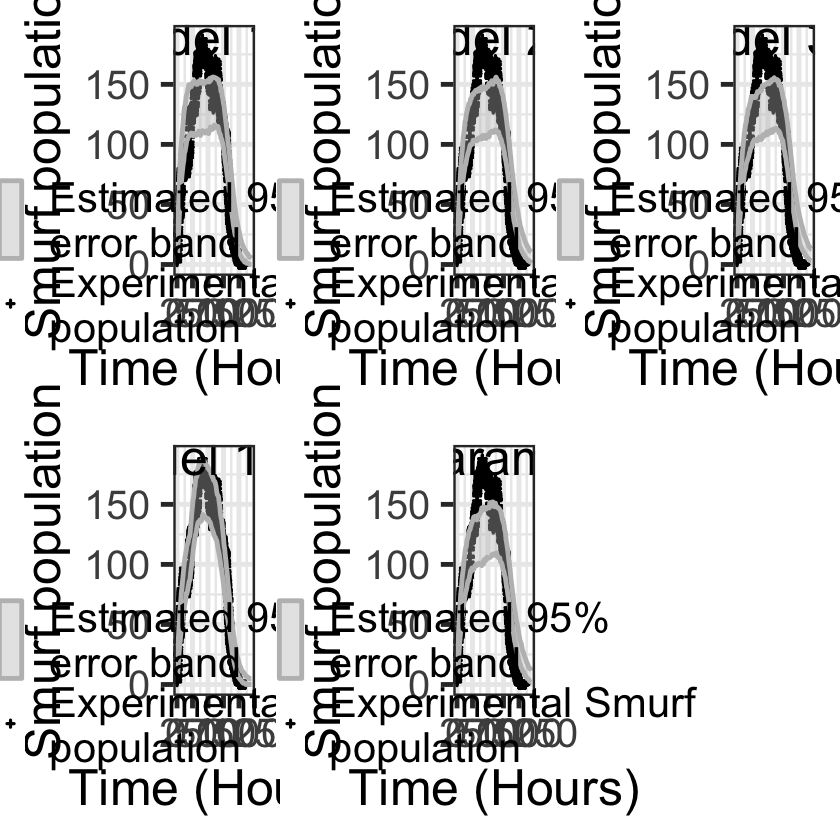

In [73]:
#Figure S5
#Estimated pointwise 95% confidence intervals for Smurf population over time vs data for models 1, 2, 3, 12 and non-parametric 

CIs1 = smurf_CI('gm', 1, c(f,g,h), c(kDi), smurf_exp,nrep=500) #CI model 1
CIs2 = smurf_CI('gm', 2, c(f,g,h), c(kD1i,kD2i), smurf_exp,nrep=500) #CI model 2
CIs3 = smurf_CI('gm', 3, c(f,g,h), c(kD1ei, kD2ei,d_ei), smurf_exp,nrep=500) #CI model 3
CIs12 = smurf_CI('gm', 12, c(f,g,h), 
        c(kD1e_12_s1, kD2e_12_s1,d_12_s1,kD1e_12_s2, kD2e_12_s2,d_12_s2,gam_sup,m_sup,lim), smurf_exp,nrep=500) #CI model 12
CIsnp = smurf_CI('gm', 'np', c(f,g,h), gam_adapt_d, smurf_exp,nrep=500) #CI non-parametric death rate

#creating data frames for ggplot
data = data.frame(time = (1:149)*10,inf1 = CIs1[1,], sup1 =  CIs1[2,],inf2 = CIs2[1,], sup2 =  CIs2[2,],inf3 = CIs3[1,], sup3 =  CIs3[2,],
infnp = CIsnp[1,], supnp =  CIsnp[2,],inf12 = CIs12[1,], sup12 =  CIs12[2,])
data2 = data.frame( th = smurf_exp, time = 1:1100)

#base plot 
G_base <- ggplot() +geom_point(data = data2, aes(time, smurf_exp, colour='Experimental Smurf\npopulation'),alpha = 1,shape=3,size = 0.5)+
theme+ theme(legend.position = c(0.4,0.2),legend.text = element_text(size=25))+ scale_color_manual(name = '', values = c('Experimental Smurf\npopulation'='black','Estimated 95%\nerror band'='grey' ))+
xlim(0,1200)+labs(x='Time (Hours)', colour='Legend', y = 'Smurf population')


P_1 <- G_base +geom_ribbon(data=data, aes(x=time,ymin = inf1, ymax = sup1,colour='Estimated 95%\nerror band'),fill='grey',alpha=0.4)+
annotate("text", x=130, y=190, label= 'Model 1') 
P_2 <- G_base +geom_ribbon(data=data, aes(x=time,ymin = inf2, ymax = sup2,colour='Estimated 95%\nerror band'),fill='grey',alpha=0.4)+
annotate("text", x=130, y=190, label= 'Model 2') 
P_3 <- G_base +geom_ribbon(data=data, aes(x=time,ymin = inf3, ymax = sup3,colour='Estimated 95%\nerror band'),fill='grey',alpha=0.4)+
annotate("text", x=130, y=190, label= 'Model 3') 
P_np <- G_base +geom_ribbon(data=data, aes(x=time,ymin = infnp, ymax = supnp,colour='Estimated 95%\nerror band'),fill='grey',alpha=0.4)+
annotate("text", x=300, y=190, label= 'Non-parametric') 
P_12 <- G_base + geom_ribbon(data=data, aes(x=time,ymin = inf12, ymax = sup12,colour='Estimated 95%\nerror band'),fill='grey',alpha=0.4)+
annotate("text", x=150, y=190, label= 'Model 12') 
#ggsave(file = "./Figures/smurf_simul_12.png",  width = 10, height = 10) 


gt<-grid.arrange(P_1,P_2,P_3, P_12,P_np,  nrow = 2) 
gt <- as_ggplot(gt)

ggsave(file = "./Figures/FigureS5.pdf",width = 21, height = 14)

### Figure S6

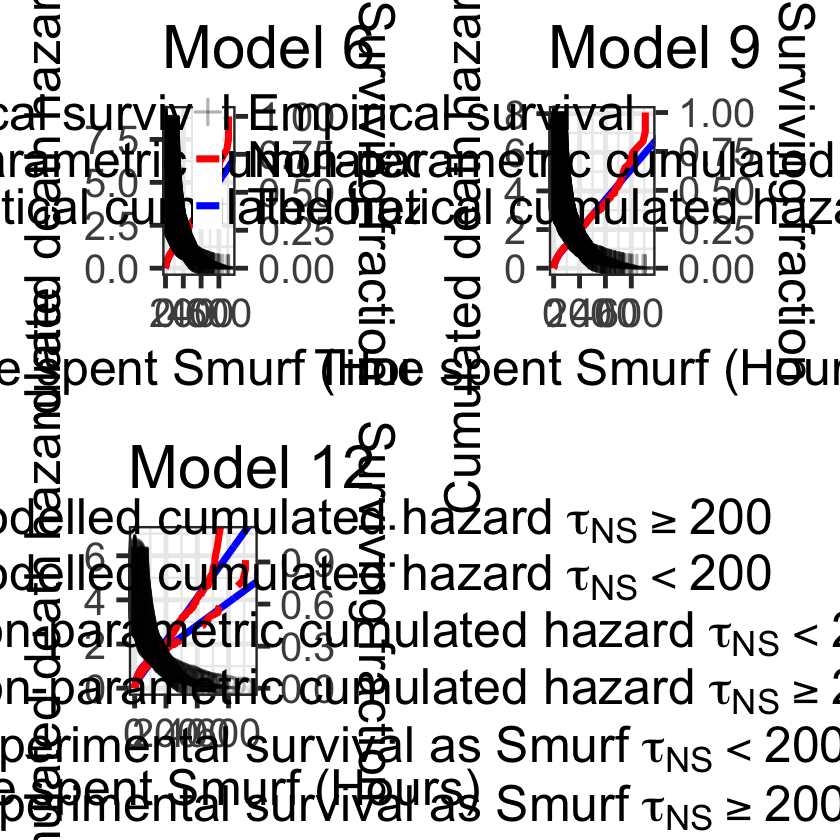

In [74]:
#Figure S6
#Plots of estimated experimental cumulated base hazard vs parametric models for models 6, 9 and 12

#Defining arrays
Ns2 = length(TS[TNS >= lim]) #sample size in strata 2
Ns1 = length(sort(TS[TNS < lim])) #sample size in strata 1
tab = list(TS,TNS)
TNS_aux = (TNS- mean(TNS[TNS>=lim])) *(TNS>=lim) #auxiliary array with 0 under lim and mean 0

#Estimation of experimental base hazard in the framework of each model, and computation of parametric base hazards

#Model 6
cox = coxph(Surv(TS,rep(1,length(TS)))~TNS,tab) #Cox model model 6
b_haz = basehaz(cox) #non-parametric estimated experimental base hazard for model 6
M=length(b_haz$time)
cum_haz_th = sapply(0:(length(TS)), function(t)(kD1e_6*t - kD2e_6/d_6*(exp(-d_6*t)-1))) #parametric base hazard model 6
data6 = data.frame(surv = length(TD):0, T = c(0,sort(TS)), th = cum_haz_th, timeth = 0:(length(TS)))  #dataframe for plot             
coef6 = max(b_haz$hazard)/1159 #rescaling coefficient for plot

#Model 9
cox_9 = coxph(Surv(TS,rep(1,length(TS)))~TNS_aux) #Cox model model 9 (for time spent non-Smurf > 200 hours)
b_haz9 = basehaz(cox_9)#non-parametric estimated experimental base hazard for model 9 (for time spent non-Smurf > 200 hours)
cum_haz_th9 = sapply(0:length(TS), function(t)(kD1e_9*t - kD2e_9/d_9*(exp(-d_9*t)-1))) #parametric base hazard model 9 
data9 = data.frame(surv = length(TS):0, T = c(0,sort(TS)), th = cum_haz_th9, timeth = 0:(length(TS))) #dataframe for plot             
coef9 = max(b_haz9$hazard)/1159 #rescaling coefficient for plot

    
#Model 12
cox_12 = coxph(Surv(TS[TNS >=lim],rep(1,length(TS[TNS >=lim])))~TNS[TNS >=lim]) #Cox model model 12 (for time spent non-Smurf > 200 hours)
b_haz12 = basehaz(cox_12) #non-parametric estimated experimental base hazard for model 12 strata 2(for time spent non-Smurf > 200 hours)
df_t = data.frame('times' = TS[TNS < lim], 'dead' = rep(1,length(TS[TNS < lim]))) #array to compute estimated base hazard strata 1
base = sort(nelsonaalen(df_t, 'times', 'dead'))#non-parametric estimated experimental base hazard for model 12 strata 1 (for time spent non-Smurf <= 200 hours)
cum_haz_th2 = sapply(0:length(TS), function(t)(kD1e_12_s2*t - kD2e_12_s2/d_12_s2*(exp(-d_12_s2*t)-1))) #parametric base hazard model 12 strata 2
cum_haz_th1 = sapply(0:length(TS), function(t)(kD1e_12_s1*t - kD2e_12_s1/d_12_s1*(exp(-d_12_s1*t)-1))) #parametric base hazard model 12 strata 1
data2 = data.frame(base, times = sort(TS[TNS < lim]),surv = (Ns1:1)/Ns1)  #dataframe for plot
data3 = data.frame(times = sort(TS[TNS >= lim]), surv = (Ns2:1)/Ns2)   #dataframe for plot                   
data = data.frame(surv = length(TS):0, T = c(0,sort(TS)), th2 = cum_haz_th2,th1 =  cum_haz_th1, timeth = 0:(length(TS)))  #dataframe for plot
coef12 = max(base)  #rescaling coefficient for plot


                     
#Plots 
#Model 6          
H_6 <-  ggplot() +geom_line(data =data6, aes(x=timeth,y= th ,colour = 'Theoretical cumulated hazard'),linewidth = 2) +
geom_line(aes(x=time, y = hazard,color='Non-parametric cumulated hazard'),b_haz, linewidth = 2)+
scale_y_continuous(
    # Features of the first axis
    name = "Cumulated death hazard rate",
    # Add a second axis and specify its features
    sec.axis = sec_axis(~./max(b_haz$hazard)+min(b_haz$hazard)/(max(b_haz$hazard)), name="Surviving fraction")
  ) +
geom_point(data = data6, aes(T, surv*coef6+min(b_haz$hazard), colour='Empirical survival'),alpha = 0.3,shape=3)+
theme+
scale_color_manual(name = "", values = c('Theoretical cumulated hazard'='blue', 'Empirical survival'='black','Non-parametric cumulated hazard'='red' ))+
labs(x='Time spent Smurf (Hours)', colour='Legend',title = 'Model 6')+coord_cartesian( ylim = c(0, 9),xlim = c(0,750))+
theme(legend.position = c(0.52, 0.9))


#Model 9              
H_9 <- ggplot() +geom_line(data =data9, aes(x=timeth,y= th ,colour = 'Theoretical cumulated hazard'),linewidth = 2) +
geom_line(aes(x=time, y = hazard,color='Non-parametric cumulated hazard'),b_haz9,linewidth = 2)+
scale_y_continuous(
    # Features of the first axis
    name = "Cumulated death hazard rate",
    # Add a second axis and specify its features
    sec.axis = sec_axis(~./max(b_haz9$hazard)+min(b_haz9$hazard)/(max(b_haz9$hazard)), name="Surviving fraction")
  ) +
geom_point(data = data9, aes(T, surv*coef9+min(b_haz9$hazard), colour='Empirical survival'),alpha = 0.3,shape=3)+
theme+
scale_color_manual(name = "", values = c('Theoretical cumulated hazard'='blue', 'Empirical survival'='black','Non-parametric cumulated hazard'='red' ))+
labs(x='Time spent Smurf (Hours)', colour='Legend',title = 'Model 9')+coord_cartesian( ylim = c(0, 8),xlim=c(0,750))+
theme(legend.position = c(0.52, 0.9))



#Model 12                   
 H_12 <- ggplot() +geom_line(data =data, aes(x=timeth,y= th2 ,colour = 'Cumul2'),linewidth = 2) +
geom_line(data =data, aes(x=timeth,y= th1 ,colour = 'Cumul1'),linewidth = 2, linetype = 'dashed')+
geom_line(aes(x=time, y = hazard,color='Nonpar2'),b_haz12,linewidth = 2)+
geom_line(data = data2, aes(x=times, y = base,color='Nonpar1'),linewidth = 2,linetype = 'dashed')+
scale_y_continuous(
    # Features of the first axis
    name = "Cumulated death hazard rate",
    # Add a second axis and specify its features
    sec.axis = sec_axis(~./max(base)+min(base)/(max(base)), name="Surviving fraction")
  ) +
geom_point(data = data2, aes(times, surv*coef12+min(base), colour='Surv1'),alpha = 0.2,shape=1)+
geom_point(data = data3, aes(times, surv*coef12+min(base), colour='Surv2'),shape=3,alpha = 0.2)+
theme+
scale_color_manual(name = "", values = c('Cumul2'='blue','Cumul1'='blue', 'Surv2'='black','Nonpar1'='red','Nonpar2'='red',
                                         'Surv1'='black' ), 
labels = c( "Cumul2" = TeX('Modelled cumulated hazard $\\tau_{NS} < 200$'),"Cumul1" = TeX('Modelled cumulated hazard $\\tau_{NS} \\geq 200$'),
          "Nonpar1"= TeX('Non-parametric cumulated hazard $\\tau_{NS} < 200$'),"Nonpar2"= TeX('Non-parametric cumulated hazard $\\tau_{NS} \\geq 200$'),
          'Surv1' = TeX('Experimental survival as Smurf $\\tau_{NS} < 200$'),
           'Surv2' = TeX('Experimental survival as Smurf $\\tau_{NS} \\geq 200$')))+ 
#scale_linetype_manual( breaks = c("Cumul1", "Cumul2", "Nonpar1", "Nonpar2"), values = c("Cumul2" = "solid", "Cumul1" = "dashed", "Nonpar2" = "solid","Nonpar1" = "dashed")) +
theme(legend.position = c(1.8, 0.4),legend.key.width = unit(5, "line"))+
labs(x='Time spent Smurf (Hours)', colour='Legend',title = 'Model 12')+coord_cartesian( ylim = c(0, 7),xlim=c(0,750))

gt<-grid.arrange(H_6,H_9,H_12,nrow = 2)
gt <- as_ggplot(gt)
                     
ggsave(file = "./Figures/FigureS6.pdf",  width = 20, height = 20) 

### Table S2

In [53]:
#Table S2
#BIC and log-likelihood comparison of experimental total lifetime vs 2 phase models vs 1 phase models


#Model 6
log_1d = sum(log(sapply(TD,function(t)(df_td_dep_cont(t,gam,m,kD1e_6, kD2e_6,d_6,f,g,h)))) )                 
BIC_1d = -2*log_1d +7*log(N) 
#Model 9
log_2d = sum(log(sapply(TD,function(t)(df_td_2dep_cont(t,gam_sup,m_sup,lim,kD1e_9, kD2e_9,d_9,f,g,h)))))
BIC_2d = -2*log_2d +8*log(N)
#Model 12
log_2ds = sum(log(sapply(TD,function(t)(df_td_2dep_strat(t,gam_sup,m_sup,lim,kD1e_12_s1, kD2e_12_s1,d_12_s1,kD1e_12_s2, kD2e_12_s2,d_12_s2,f,g,h)))))
BIC_2ds = -2*log_2ds +11*log(N) #BIC 2PAC w/ conditional dependence tot pop
#Gompertz-Makeham apparent death rate                        
log_gm =  sum(log(sapply(TD,function(x) (dis_makeham(x,j,n,l)))))
BIC_gm = -2*log_gm +3*log(N) 
#Gamma Gompertz apparent death rate                        
log_gamg =  sum(log(alpha*s*exp(alpha*TD)*beta^(s)/(beta-1+exp(alpha*TD))^(s+1)))                        
BIC_gamg = -2*log_gamg + 3*log(N) 
#Generalized Gamma apparent death rate                        
log_gg = sum(log(p/r^q*TD^(q-1) *exp(-(TD/r)^p)/gamma(q/p)))
BIC_gg = -2*log_gg + 3*log(N)

#Printing results
print(paste('Model 6 BIC: ', BIC_1d, 'Log-likelihood: ', log_1d))
print(paste('Model 9 BIC: ', BIC_2d, 'Log-likelihood: ', log_2d))
print(paste('Model 12 BIC: ', BIC_2ds, 'Log-likelihood: ', log_2ds))
print(paste('Gompertz-Makeham BIC: ', BIC_gm, 'Log-likelihood: ', log_gm))
print(paste('Gamma-Gompertz BIC: ', BIC_gamg, 'Log-likelihood: ', log_gamg))
print(paste('Generalized Gamma BIC: ', BIC_gg, 'Log-likelihood: ', log_gg))

[1] "Model 6 BIC:  15941.2518932484 Log-likelihood:  -7945.93235167249"
[1] "Model 9 BIC:  15926.4466666854 Log-likelihood:  -7935.00208196934"
[1] "Model 12 BIC:  15936.3474812131 Log-likelihood:  -7929.3695199682"
[1] "Gompertz-Makeham BIC:  15890.7244355625 Log-likelihood:  -7934.77924851626"
[1] "Gamma-Gompertz BIC:  15941.2816461658 Log-likelihood:  -7960.05785381791"
[1] "Generalized Gamma BIC:  16163.3278625914 Log-likelihood:  -8071.08096203069"


In [54]:
#Wassersein distance comparison for total lifetime models, experimental vs 2 phase vs 1 phase 

#theoretical apparent death hazard rate for model 12
Haz_th = sapply(c((0:200)*3,(60:100)*10) , function(c)(haz_death(c,gam_sup,m_sup,lim,kD1e_12_s1, kD2e_12_s1,d_12_s1,kD1e_12_s2, kD2e_12_s2,d_12_s2,f,g,h)))

#Creating functions for simulation
gm = IBMPopSim::linfun(0:1000, sapply(0:1000,function(c)(j+n*exp(l*c))),0,0)
gg = IBMPopSim::linfun(0:1000, hgengamma.orig(0:1000,p,r,q),0,0)
gamg =  IBMPopSim::linfun(0:1000,sapply(0:1000,function(c)(alpha*s*exp(alpha*c)/(beta-1+exp(alpha*c)))),0,0)
model12 = IBMPopSim::linfun(c((0:200)*3,(60:100)*10), Haz_th)
model9 = IBMPopSim::linfun(c((0:200)*3,(60:81)*10,(85:92)*10,950,1000), Haz_th_9)
Haz_th_6 = sapply(c((0:200)*3,(60:100)*10) , function(c)(haz_death6(c,gam,m,kD1e_6,kD2e_6,d_6,f,g,h)))
model6 = IBMPopSim::linfun(c((0:200)*3,(60:100)*10), Haz_th_6)

#Wasserstein distances 
was_gm = emp_wasserstein1D('np',TD,gm,n=400,K=300) #gompertz-makeham apparent death rate
was_gg = emp_wasserstein1D('np',TD,gg,n=400,K=300) #generalized gamma apparent death rate
was_gamg = emp_wasserstein1D('np',TD,gamg,n=400,K=300) #gamma-gompertz apparent death rate
was_12 = emp_wasserstein1D('np',TD,model12,n=400,K=300)#model 12
was_9 = emp_wasserstein1D('np',TD,model9,n=400,K=300)#model 9
was_6 = emp_wasserstein1D('np',TD,model6,n=400,K=300)#model 6

Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“suppression des ex-aequos de 'x'”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“suppression des ex-aequos de 'x'”
Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
“suppression des ex-aequos de 'x'”


### Figure S7

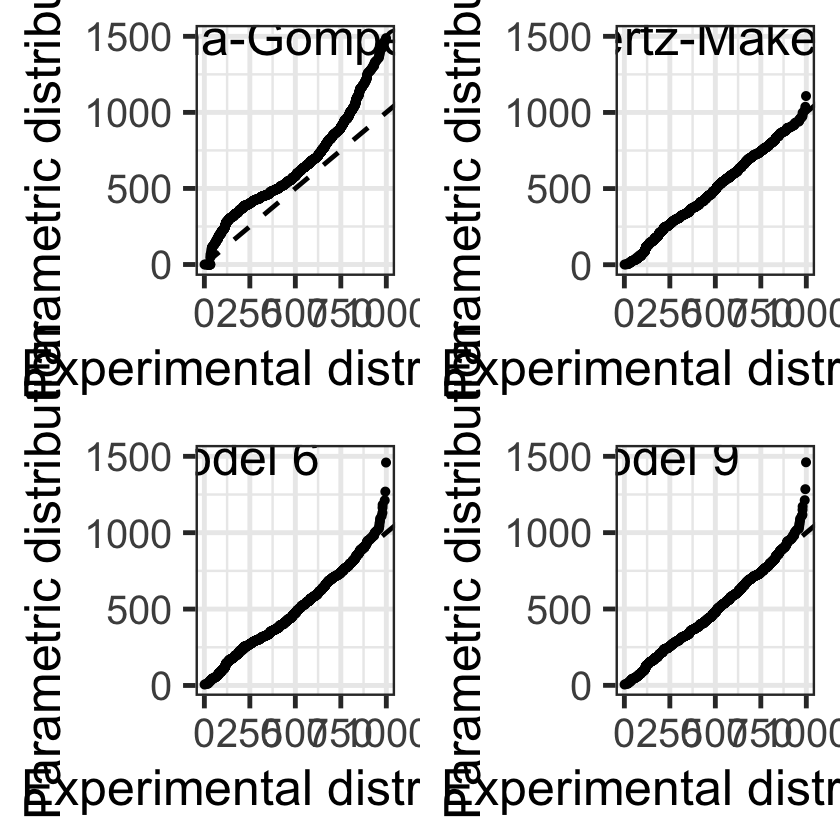

In [75]:
#Figure S7
##QQ-plots to compare the experimental distribution of total lifetime to theoretical distributions (1 and 2 phases)
quant = (1:length(TD))/length(TD) #experimental quantiles

Tgm = plot_qq_pop('np','np',gm,gm,'s',12000)
Tgm = quantile(Tgm, quant) #quantiles Gompertz-Makeham apparent death rate

Tgg = plot_qq_pop('np','np',gg,gm,'s',12000)
Tgg = quantile(Tgg, quant) #quantiles Generalized Gamma apparent death rate

T6 = plot_qq_pop('np','np',model6,gm,'s',12000)
T6 = quantile(T6, quant) #quantiles model 6

T9 = plot_qq_pop('np','np',model9,gm,'s',12000)
T9 = quantile(T9, quant) #quantiles model 9

T12 = plot_qq_pop('np','np',model12,gm,'s',12000)
T12 = quantile(T12, quant) #quantiles model 12

data = data.frame(Tgm,Tgg,T9,T6,TD)#dataframe for plot

#Plots
P_gg <- P + geom_point(mapping = aes(x = sort(TD), y = sort(Tgg)), size = 1)  + annotate("text", x=300, y=1500, label= 'Gamma-Gompertz') 
P_gm <- P + geom_point(mapping = aes(x = sort(TD), y = sort(Tgm)), size = 1) + annotate("text", x=350, y=1500, label= 'Gompertz-Makeham') 
P_9 <- P + geom_point(mapping = aes(x = sort(TD), y = sort(T9)), size = 1) + annotate("text", x=150, y=1500, label= 'Model 9') 
P_6 <- P + geom_point(mapping = aes(x = sort(TD), y = sort(T6)), size = 1) + annotate("text", x=150, y=1500, label= 'Model 6') 


gt<-grid.arrange(P_gg,P_gm,P_6,P_9, nrow = 2)
gt <- as_ggplot(gt)
ggsave(file = "./Figures/FigureS7.pdf",width = 15, height = 15)

### Figure S8

In [55]:
surv_lines = read.csv('./Data/surv_lines.csv',sep=';') #loading survival data 
D_377 = surv_lines$X377 #survival function of line 377
X_377 = transf_surv(D_377) #transforms survival function into (censored) individual death times
X_377 = X_377[X_377>(264)]-264 #translation of 11 days to match with the framework


s_377 = c(6/257,3/244,1/229,7/197,41/129,8/10) #aggregated observed proportion of Smurf 
t_s = c(9,17,26,36,41,51)*24 #time steps for Smurf proportion observations

#Observed proportions of Smurf for each tube for confidence interval
prop_377_tube_9= c(0,0,0,0,1/24,1/26,2/26,1/17,1/23)
prop_377_tube_17= c(0,2/25,0,0,0,0,0,0,1/22)
prop_377_tube_26= c(0,0,0,0,0,1/21,0,0,0,0,0)
prop_377_tube_36 = c(0,1/20,0,0,0,1/18,0,0,5/10)
prop_377_tube_46= c(8/15,3/10,6/12,2/17,5/18,2/11,4/16,8/17,3/3)
prop_377_tube_54= c(2/2,2/2,2/2,1/1,1/3)


#initialisation of parameters with values that were fitted on the initial dataset for model 6
f0 <- f
g0 <- g
h0 <- h
kd10 <- kD1e_6*exp(-gam*m)
kd20 <- kD2e_6*exp(-gam*m)
d0 <- d_6
gam0 <- gam

thet_0 = c(f0,g0,h0,kd10,kd20,d0,gam0) #full parameter array

#fitting parameters g and h with two grid searches
thet_3770<- thet_0 #initialising parameters
init_gh1 = grid_search_1p(thet_3770,X_377,0, f*10) #first grid search for parameter f
thet_3770[1]<- init_gh1
init_gh = grid_search(thet_3770,X_377,0.1*g0,10*g0,0.7*h0,1.7*h0) #second grid search for g and h
#updating parameter values
thet_3770[2]<- init_gh[1]
thet_3770[3]<- init_gh[2]
g1 =  init_gh[1]
h1 = init_gh[2]
init_gh2 = grid_search(thet_3770,X_377,0.1*g1,2*g1,0.8*h1,1.2*h1) #third grid search for more precision on g and h
#updating parameter values
thet_3770[2]<- init_gh2[1]
thet_3770[3]<- init_gh2[2]

surv_th_377 = sapply((0:200)*12, function(i)(survival_tot(i,thet_3770))) #modelled survival with fitted parameters
smurf_th_377 = sapply((1:200)*12, function(i)(Smurf_th_1dep(i,thet_3770))) #modelled Smurf proportion with fitted parameters

stde = 1.96/sqrt(9)*c(sqrt(var(prop_377_tube_9)),sqrt(var(prop_377_tube_17)),
                      sqrt(var(prop_377_tube_26)),sqrt(var(prop_377_tube_36)),
                      sqrt(var(prop_377_tube_46)),sqrt(9/7)*sqrt(var(prop_377_tube_54))) #error bars for Smurf proportion

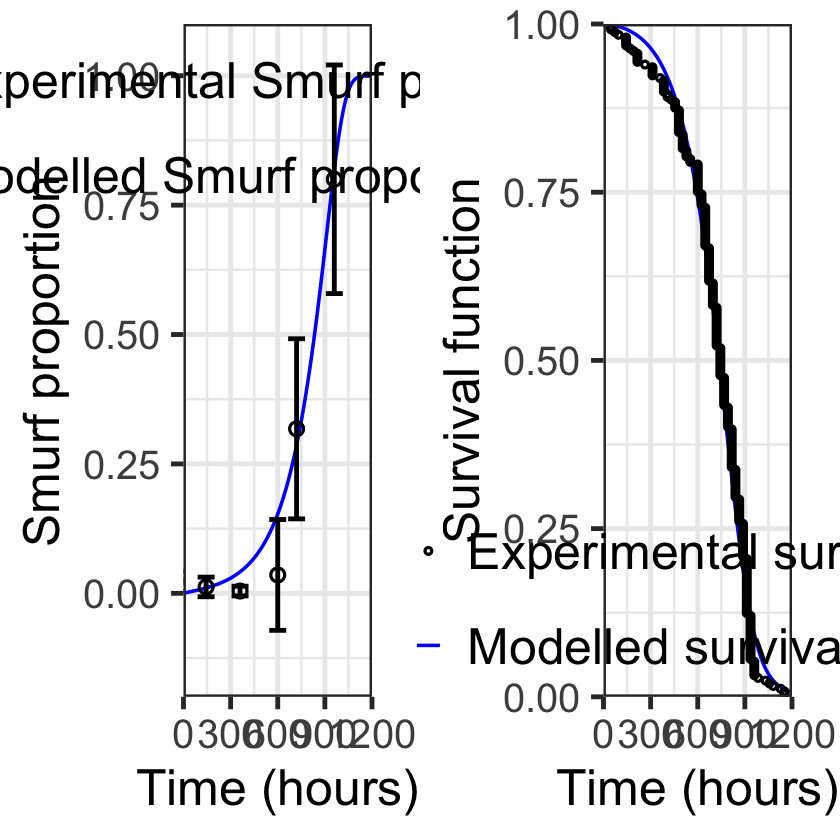

In [76]:
#Figure S8
#dataframes for plotting
data_377 = data.frame(time =(1:200)*12 , prop= (smurf_th_377 + surv_th_377[1:200]-surv_th_377[2:201]) / (surv_th_377[1:200]) )              
data_error = data.frame(t_exp =  c(9,17,26,36,41,51)*24 - 264, sup = s_377+stde, inf = s_377-stde, prop = s_377)

data_surv = data.frame(time = (0:200)*12, surv = surv_th_377)
data_surv_e = data.frame(time = sort(X_377),surv = (length(X_377):1)/length(X_377))

#Plots 
g_377 <- ggplot()+ 
geom_line(data = data_377, aes(x=time, y =prop,colour = 'Modelled Smurf proportion'),lwd = 1)+
geom_errorbar(data = data_error, aes(x= t_exp, ymin = inf, ymax = sup))+
geom_point(data = data_error, aes(t_exp,prop, colour='Experimental Smurf proportion'),alpha = 1,shape=1,size = 3)+
scale_y_continuous(expand = c(0, 0),
    # Features of the first axis
    name = "Smurf proportion")+ theme+
coord_cartesian(xlim = c(0,1200), ylim = c(-0.2,1.1))+scale_x_continuous(expand = c(0, 0))+ 
theme( legend.key.height = unit(2, "cm"),legend.position = c(0.4, 0.9),plot.margin = unit(c(1, 2, 1, 1), "lines"))+
scale_color_manual(name = "", values = c('Modelled Smurf proportion' = 'blue', 'Experimental Smurf proportion' = 'black'
                                        ))+labs(y ='Smurf proportion',x='Time (hours)')

g_377_s <- ggplot()+ 
geom_line(data = data_surv, aes(x=time, y =surv,colour = 'Modelled survival'),lwd = 1)+
geom_point(data = data_surv_e, aes(x=time,y=surv, colour='Experimental survival'),alpha = 1,shape=1,size = 1)+
scale_y_continuous(expand = c(0, 0),
    # Features of the first axis
    name = "Survival function")+ theme+
coord_cartesian(xlim = c(0,1200), ylim = c(0,1))+scale_x_continuous(expand = c(0, 0))+ 
theme( legend.key.height = unit(2, "cm"),legend.position = c(0.4, 0.2),plot.margin = unit(c(1, 2, 1, 1), "lines"))+
scale_color_manual(name = "", values = c('Modelled survival' = 'blue', 'Experimental survival' = 'black'
                                        ))+labs(y ='Population survival',x='Time (hours)')

G_377 <-grid.arrange(g_377, g_377_s, nrow = 1)
G_377 <- as_ggplot(G_377)
ggsave(file = "./Figures/FigureS8.pdf",  width = 20, height = 10) 